This analysis examines 4 years of retail transaction data (2014–2017)
across 9,994 orders spanning 3 product categories, 4 regions, and
3 customer segments in the United States.

Despite generating $2.3M in total revenue, the business achieved only
a 12.5% overall profit margin -- significantly below healthy retail
benchmarks. This analysis identifies three structural profit leaks:

- **DISCOUNT TRAP**
  Transactions with discounts above 20% consistently generate losses
  across all categories. 856 transactions with 50%+ discounts alone
  wiped out $76,559 in profit.

- **CATEGORY IMBALANCE**  
  Furniture generates $742K in revenue but only 2.49% profit margin
  -- compared to 17% for Technology and Office Supplies. Three
  sub-categories (Tables, Bookcases, Supplies) are operating at
  a net loss.

- **REGIONAL DISPARITY**
  The Central region delivers only 7.92% margin versus West's 14.94%
  -- a gap that suggests structural pricing or discount policy
  differences, not demand issues.

**Key Finding:**
Revenue growth is being systematically undermined by aggressive
discount strategies concentrated in already low-margin categories.

**Strategic Implication:**
Eliminating discounts above 20% and reviewing Furniture sub-category
pricing could recover an estimated $50,000–$80,000 in annual profit
without requiring any increase in sales volume.

# Business Problem

# Context
A mid-size U.S. retail company operates across four regions --
East, West, Central, and South -- selling products across three
categories Furniture, Office Supplies, and Technology.

Over the past four years (2014–2017), the company has successfully
grown its customer base and order volume, Revenue has been
increasing year over year.

# The Problem
Despite revenue growth, profitability has not followed the same
trajectory.

The company is generating $2.3M in revenue but walking away with
only $286,397 in total profit -- an overall margin of 12.5%.

More critically some product lines and regions are actively
losing money, quietly offset by high performers.


# Symptoms Observed
- Certain product categories show high sales but near-zero margins
- Discount rates vary widely across transactions -- some reaching 80%
- Regional performance is inconsistent despite similar product mix
- Some sub-categories have been operating at a net loss for years

# The Core Question
Is this company growing revenue at the expense of profit?
And if so — where exactly is the value being destroyed,
and what can be done about it?

# Analysis Objectives
This analysis aims to answer five specific business questions:

- Which product categories and sub-categories are profit drains?
- At what discount threshold does profitability turn negative?
- Which regions underperform -- and why?
- Which customer segments drive the most (and least) value?
- What specific actions can recover profit without cutting revenue?

# Dataset Understanding

# Source
Dataset: Sample Superstore (Kaggle)
Period : January 2014 – December 2017 (4 years)
Scope  : United States retail transactions
Size   : 9,994 rows × 21 columns
Missing: None — dataset is complete

# What Each Row Represents
Each row is a single line item from a customer order.
One order can have multiple rows (multiple products).
This distinction matters: order-level analysis vs.
transaction-level analysis will yield different results.


# Key Characteristics Found in This Dataset

- Discount range: 0% to 80%
   Some transactions carry discounts as high as 80% --
   this is unusual and worth investigating whether these
   are pricing errors or deliberate clearance strategies.

- Profit can be negative
   Min profit per transaction: -$6,599
   This means individual transactions can destroy
   significant value — not just break even.

- Sales and Profit are NOT correlated linearly
   High-sales transactions don't always mean high profit.
   This is the central tension of the entire analysis.

- No customer demographic data
   We cannot analyze by age, income, or behavior beyond
   segment label (Consumer / Corporate / Home Office).
   Recommendations will be product and region focused,
   not customer persona focused.

# Dataset Limitations (Analyst Honesty)
- Data ends at 2017 -- trends may not reflect current market
- No cost structure data -- we cannot separate COGS from discount loss
- Geographic granularity stops at Region -- state-level
  patterns exist but require deeper drill-down
- No competitor or market data for benchmarking margins

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('SampleSuperstore.csv', encoding='latin-1')

print("Shape       :", df.shape)
print("Duplicates  :", df.duplicated().sum())
print("Missing vals:\n", df.isnull().sum()[df.isnull().sum() > 0])

Shape       : (9994, 21)
Duplicates  : 0
Missing vals:
 Series([], dtype: int64)


Findings:
- 9,994 rows, 21 columns
- 0 missing values across all columns
- 0 duplicate rows
- Dataset is structurally complete — no imputation needed.

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Verifikasi
print(df[['Order Date', 'Ship Date']].dtypes)
print(df[['Order Date', 'Ship Date']].head(3))

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12 2016-06-16


Order Date and Ship Date were stored as strings.
Converted to datetime64 to enable time-series analysis
and shipping duration calculation.

In [5]:
invalid_shipping = df[df['Ship Date'] < df['Order Date']]
print("Invalid shipping dates:", len(invalid_shipping))

invalid_sales = df[df['Sales'] <= 0]
print("Invalid sales values :", len(invalid_sales))

invalid_discount = df[(df['Discount'] < 0) | (df['Discount'] > 1)]
print("Invalid discounts     :", len(invalid_discount))

invalid_qty = df[df['Quantity'] <= 0]
print("Invalid quantities    :", len(invalid_qty))

Invalid shipping dates: 0
Invalid sales values : 0
Invalid discounts     : 0
Invalid quantities    : 0


Business logic validation passed:
- No orders shipped before order date
- No zero or negative sales values  
- All discounts fall within 0–100% range
- All quantities are positive integers

Data integrity is confirmed.

In [6]:
cols_to_drop = ['Row ID', 'Country', 'Postal Code', 'Product ID']

df.drop(columns=cols_to_drop, inplace=True)

print("Remaining columns:", df.shape[1])
print(df.columns.tolist())

Remaining columns: 17
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


Dropped 4 administrative columns:
- Row ID      : internal index, no analytical value
- Country     : single value (United States), no variance
- Postal Code : too granular for this analysis scope  
- Product ID  : replaced by Product Name & Sub-Category

Working dataset: 9,994 rows × 17 columns

In [7]:
# Final clean dataset snapshot

print("=== CLEAN DATASET SUMMARY ===")
print(f"Rows         : {df.shape[0]:,}")
print(f"Columns      : {df.shape[1]}")
print(f"Date Range   : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Total Revenue: ${df['Sales'].sum():,.0f}")
print(f"Total Profit : ${df['Profit'].sum():,.0f}")
print(f"Avg Margin   : {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")

=== CLEAN DATASET SUMMARY ===
Rows         : 9,994
Columns      : 17
Date Range   : 2014-01-03 → 2017-12-30
Total Revenue: $2,297,201
Total Profit : $286,397
Avg Margin   : 12.5%


Dataset is clean, validated, and ready for feature engineering.
No data was removed — all 9,994 transactions are retained.
The cleaning process confirmed data integrity rather than
correcting errors, which increases confidence in downstream analysis.

# Feature Engineering

 **Profit Margin per Transaction**

In [8]:
df['Profit Margin'] = df['Profit'] / df['Sales']

# Verifikasi
print(df['Profit Margin'].describe().round(3))
print(f"\nTransaksi rugi : {(df['Profit Margin'] < 0).sum():,} ({(df['Profit Margin'] < 0).mean()*100:.1f}%)")
print(f"Transaksi untung: {(df['Profit Margin'] > 0).sum():,} ({(df['Profit Margin'] > 0).mean()*100:.1f}%)")

count    9994.000
mean        0.120
std         0.467
min        -2.750
25%         0.075
50%         0.270
75%         0.362
max         0.500
Name: Profit Margin, dtype: float64

Transaksi rugi : 1,871 (18.7%)
Transaksi untung: 8,058 (80.6%)


Profit Margin reveals what raw profit cannot:
a 10 profit on a 20 sale (50% margin) is fundamentally
different from a 10 profit on a 500 sale (2% margin).

Finding: 18.7% of all transactions are loss-making.
Nearly 1 in 5 orders is destroying value.

**Discount Buckets**

In [9]:
bins = [-0.01, 0.00, 0.10, 0.20, 0.30, 0.50, 1.01]

labels = ['No Discount', '0.1% - 10%', '10.1% - 20%', '20.1% - 30%', '30.1% - 50%', '50%++']

df['Discount Bucket'] = pd.cut(df['Discount'], bins=bins, labels=labels)
print(df['Discount Bucket'].value_counts().sort_index())

Discount Bucket
No Discount    4798
0.1% - 10%       94
10.1% - 20%    3709
20.1% - 30%     227
30.1% - 50%     310
50%++           856
Name: count, dtype: int64


Raw discount values (0.0, 0.1, 0.2...) are hard to interpret.
Bucketing reveals the distribution of discount strategy:
how many transactions fall into each discount tier,
and sets up the profitability threshold analysis in Section 11.

**Time Features**

In [10]:
df['Year']    = df['Order Date'].dt.year
df['Month']   = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['YearMonth'] = df['Order Date'].dt.to_period('M')

df['Ship Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Year','Month','Quarter','Ship Duration']].describe().round(1))

         Year   Month  Quarter  Ship Duration
count  9994.0  9994.0   9994.0         9994.0
mean   2015.7     7.8      2.9            4.0
std       1.1     3.3      1.1            1.7
min    2014.0     1.0      1.0            0.0
25%    2015.0     5.0      2.0            3.0
50%    2016.0     9.0      3.0            4.0
75%    2017.0    11.0      4.0            5.0
max    2017.0    12.0      4.0            7.0


Time decomposition enables:
- Year-over-year growth analysis
- Seasonality detection by month/quarter
- Peak sales period identification

Ship Duration reveals operational efficiency:
average fulfillment time and whether Ship Mode
actually correlates with faster delivery.

**Is Loss Flag**

In [11]:
df['Is Loss'] = df['Profit'] < 0

print(f"Total loss transactions: {df['Is Loss'].sum():,}")
print(f"Total profit destroyed : ${df[df['Is Loss']]['Profit'].sum():,.0f}")
print(f"As % of total profit   : {df[df['Is Loss']]['Profit'].sum()/df['Profit'].sum()*100:.1f}%")

Total loss transactions: 1,871
Total profit destroyed : $-156,131
As % of total profit   : -54.5%


Is Loss flag enables rapid filtering of unprofitable transactions
without repeatedly writing df[df['Profit'] < 0].

**Critical finding:** Loss transactions destroyed **$156,131** in value —
equivalent to wiping out 54.5% of the company's total profit.

**Revenue Tier per Customer**

In [12]:
customer_revenue = df.groupby('Customer ID')['Sales'].sum()

df['Customer Revenue Tier'] = df['Customer ID'].map(customer_revenue).apply(
    lambda x: 'High Value'   if x >= 5000  else
              'Mid Value'    if x >= 1000  else
              'Low Value'
)

print(df['Customer Revenue Tier'].value_counts())
print(df.groupby('Customer Revenue Tier')[['Sales','Profit']].sum().round(0))

Customer Revenue Tier
Mid Value     6668
High Value    2173
Low Value     1153
Name: count, dtype: int64
                           Sales    Profit
Customer Revenue Tier                     
High Value              911958.0  140313.0
Low Value                92333.0   11174.0
Mid Value              1292909.0  134910.0


Revenue tier classifies customers by lifetime spend,
enabling segment-level profitability analysis beyond
the standard Consumer/Corporate/Home Office labels.

This sets up Section 10 (Customer Segment Analysis)
to answer: do high-revenue customers also drive high profit?
Or are we discounting heavily to retain them?

**Feature Engineering Summary**

In [13]:
print("=== NEW FEATURES CREATED ===\n")
new_features = {
    'Profit Margin'         : 'Profit as % of Sales per transaction',
    'Discount Bucket'       : 'Categorical discount tier (6 levels)',
    'Year / Month / Quarter': 'Time decomposition for trend analysis',
    'YearMonth'             : 'Period index for time-series plotting',
    'Ship Duration'         : 'Days between order and delivery',
    'Is Loss'               : 'Binary flag for loss-making transactions',
    'Customer Revenue Tier' : 'High/Mid/Low value customer classification',
}

for feature, purpose in new_features.items():
    print(f"  {feature:<28} → {purpose}")

print(f"\nFinal dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

=== NEW FEATURES CREATED ===

  Profit Margin                → Profit as % of Sales per transaction
  Discount Bucket              → Categorical discount tier (6 levels)
  Year / Month / Quarter       → Time decomposition for trend analysis
  YearMonth                    → Period index for time-series plotting
  Ship Duration                → Days between order and delivery
  Is Loss                      → Binary flag for loss-making transactions
  Customer Revenue Tier        → High/Mid/Low value customer classification

Final dataset: 9,994 rows × 26 columns


7 new features engineered from existing columns.
No external data added — all derivations are
mathematically defensible from the source data.

These features transform raw transaction records into
an analytically rich dataset capable of answering
the 5 business questions defined in Section 2.

Feature engineering is now complete. Analysis begins.

# Executive KPI Overview

**Core KPI Calculation**

In [14]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [15]:
# === CORE KPIs ===
total_revenue      = df['Sales'].sum()
total_profit       = df['Profit'].sum()
overall_margin     = total_profit / total_revenue * 100
total_orders       = df['Order ID'].nunique()
total_customers    = df['Customer ID'].nunique()
total_transactions = len(df)
loss_transactions  = df['Is Loss'].sum()
loss_rate          = loss_transactions / total_transactions * 100
avg_discount       = df['Discount'].mean() * 100
profit_destroyed   = df[df['Is Loss']]['Profit'].sum()

print("=== EXECUTIVE KPI SNAPSHOT ===")
print(f"Total Revenue       : ${total_revenue:>12,.0f}")
print(f"Total Profit        : ${total_profit:>12,.0f}")
print(f"Overall Margin      : {overall_margin:>11.1f}%")
print(f"Total Orders        : {total_orders:>12,}")
print(f"Total Customers     : {total_customers:>12,}")
print(f"Loss Transactions   : {loss_transactions:>12,} ({loss_rate:.1f}%)")
print(f"Avg Discount Applied: {avg_discount:>11.1f}%")
print(f"Profit Destroyed    : ${profit_destroyed:>12,.0f}")

=== EXECUTIVE KPI SNAPSHOT ===
Total Revenue       : $   2,297,201
Total Profit        : $     286,397
Overall Margin      :        12.5%
Total Orders        :        5,009
Total Customers     :          793
Loss Transactions   :        1,871 (18.7%)
Avg Discount Applied:        15.6%
Profit Destroyed    : $    -156,131


**KPI Cards (Plotly)**

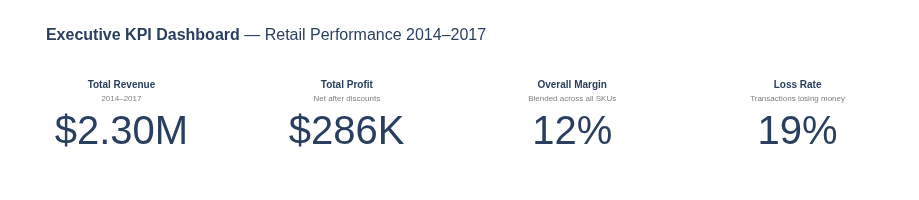

In [16]:
fig_kpi = go.Figure()

kpis = [
    {
        "title" : "Total Revenue",
        "num"   : total_revenue / 1e6,
        "prefix": "$",
        "suffix": "M",
        "sub"   : "2014–2017",
    },
    {
        "title" : "Total Profit",
        "num"   : total_profit / 1e3,
        "prefix": "$",
        "suffix": "K",
        "sub"   : "Net after discounts",
    },
    {
        "title" : "Overall Margin",
        "num"   : overall_margin,
        "prefix": "",
        "suffix": "%",
        "sub"   : "Blended across all SKUs",
    },
    {
        "title" : "Loss Rate",
        "num"   : loss_rate,
        "prefix": "",
        "suffix": "%",
        "sub"   : "Transactions losing money",
    },
]

for i, kpi in enumerate(kpis):
    fig_kpi.add_trace(go.Indicator(
        mode   = "number",
        value  = kpi["num"],
        title  = {
            "text": (
                f"<b>{kpi['title']}</b><br>"
                f"<span style='font-size:0.8em;color:gray'>{kpi['sub']}</span>"
            )
        },
        number = {
            "prefix" : kpi["prefix"],
            "suffix" : kpi["suffix"],
            "font"   : {"size": 40},
            "valueformat": ".2f" if kpi["suffix"] == "M" else ".0f",
        },
        domain = {"row": 0, "column": i},
    ))

fig_kpi.update_layout(
    grid   = {"rows": 1, "columns": 4},
    height = 200,
    margin = dict(t=80, b=20, l=20, r=20),
    title  = {
        "text": "<b>Executive KPI Dashboard</b> — Retail Performance 2014–2017",
        "font": {"size": 16},
    },
)

fig_kpi.show()

**Profit Breakdown by Category (Bar)**

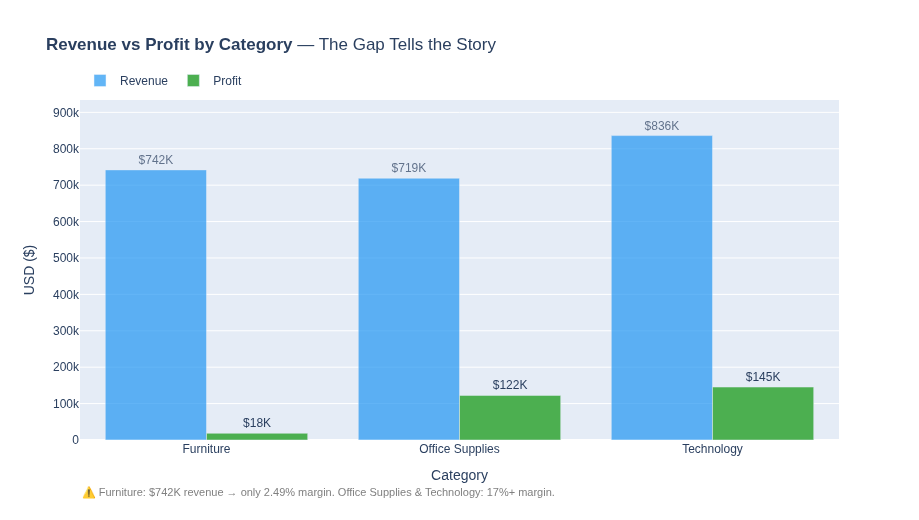

In [17]:
cat_perf = df.groupby('Category').agg(
    Revenue=('Sales',  'sum'),
    Profit =('Profit', 'sum')
).reset_index()
cat_perf['Margin'] = cat_perf['Profit'] / cat_perf['Revenue'] * 100

fig_cat = go.Figure()

fig_cat.add_trace(go.Bar(
    name='Revenue', x=cat_perf['Category'], y=cat_perf['Revenue'],
    marker_color='#2196F3', opacity=0.7,
    text=cat_perf['Revenue'].apply(lambda x: f'${x/1e3:.0f}K'),
    textposition='outside'
))

fig_cat.add_trace(go.Bar(
    name='Profit', x=cat_perf['Category'], y=cat_perf['Profit'],
    marker_color='#4CAF50',
    text=cat_perf['Profit'].apply(lambda x: f'${x/1e3:.0f}K'),
    textposition='outside'
))

fig_cat.update_layout(
    barmode = 'group',
    title   = '<b>Revenue vs Profit by Category</b> — The Gap Tells the Story',
    xaxis_title = 'Category',
    yaxis_title = 'USD ($)',
    height  = 520,
    legend  = dict(orientation='h', y=1.1),
    annotations=[dict(
        x=0, y=-0.18, xref='paper', yref='paper',
        text="⚠️ Furniture: $742K revenue → only 2.49% margin. "
             "Office Supplies & Technology: 17%+ margin.",
        showarrow=False, font=dict(size=11, color='gray')
    )]
)

fig_cat.show()

**Margin Gauge per Category**

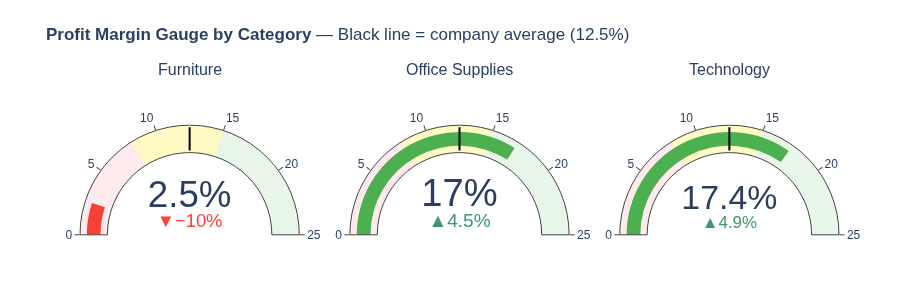

In [18]:
fig_gauge = make_subplots(
    rows=1, cols=3,
    specs=[[{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}]],
    subplot_titles=cat_perf['Category'].tolist()
)

colors = ['#F44336', '#4CAF50', '#4CAF50']  # Furniture merah, sisanya hijau

for i, row in cat_perf.iterrows():
    fig_gauge.add_trace(go.Indicator(
        mode  = "gauge+number+delta",
        value = round(row['Margin'], 1),
        delta = {"reference": 12.5, "suffix": "%"},
        number= {"suffix": "%"},
        gauge = {
            "axis" : {"range": [None, 25]},
            "bar"  : {"color": colors[i]},
            "steps": [
                {"range": [0,  8],  "color": "#ffebee"},
                {"range": [8,  15], "color": "#fff9c4"},
                {"range": [15, 25], "color": "#e8f5e9"},
            ],
            "threshold": {
                "line" : {"color": "black", "width": 2},
                "value": 12.5
            }
        },
        domain={"row": 0, "column": i}
    ), row=1, col=i+1)

fig_gauge.update_layout(
    height = 300,
    title  = '<b>Profit Margin Gauge by Category</b> — '
             'Black line = company average (12.5%)',
    margin = dict(t=80, b=20)
)

fig_gauge.show()

**Insight Callout**

The KPI overview establishes the central tension of this analysis:
a business that looks healthy on the top line (revenue growing)
but is structurally fragile on the bottom line (margin eroding).

The next sections will systematically identify where, when,
and why value is being destroyed — starting with time trends.

# Sales Trend Analysis

**Year-over-Year Performance**

In [19]:
yoy = df.groupby('Year').agg(
    Revenue     =('Sales',    'sum'),
    Profit      =('Profit',   'sum'),
    Orders      =('Order ID', 'nunique'),
    Transactions=('Sales',    'count')
).reset_index()

yoy['Margin']      = yoy['Profit'] / yoy['Revenue'] * 100
yoy['Rev Growth']  = yoy['Revenue'].pct_change() * 100
yoy['Prof Growth'] = yoy['Profit'].pct_change()  * 100

print(yoy.round(1).to_string(index=False))

 Year  Revenue  Profit  Orders  Transactions  Margin  Rev Growth  Prof Growth
 2014 484247.5 49544.0     969          1993    10.2         NaN          NaN
 2015 470532.5 61618.6    1038          2102    13.1        -2.8         24.4
 2016 609205.6 81795.2    1315          2587    13.4        29.5         32.7
 2017 733215.3 93439.3    1687          3312    12.7        20.4         14.2


Year-over-year table reveals the relationship between
revenue growth and profit growth.

If revenue grows faster than profit → margin compression.
If profit grows faster than revenue → efficiency improving.
The direction of this gap is the story of this business.

**Revenue vs Profit Trend (Dual Axis)**

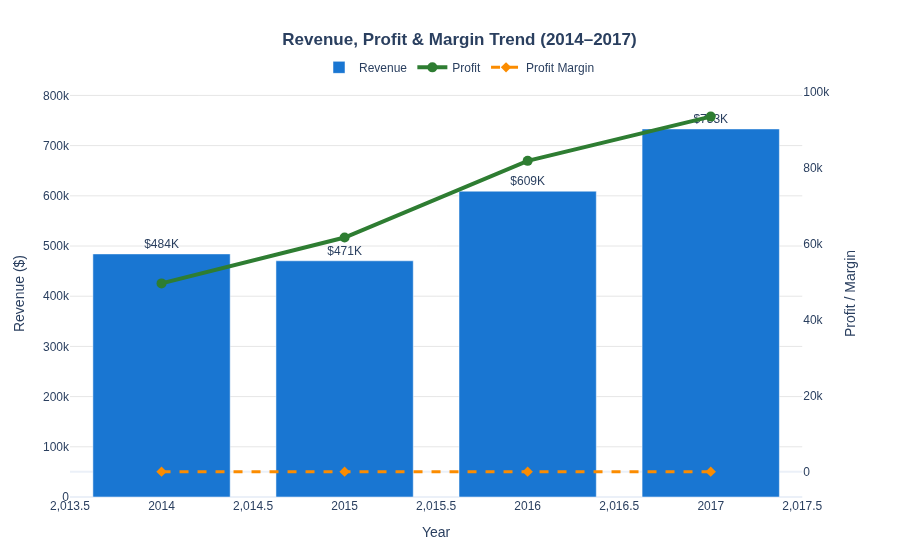

In [20]:
fig_yoy = make_subplots(
    specs=[[{"secondary_y": True}]]
)

# Revenue
fig_yoy.add_trace(
    go.Bar(
        x=yoy["Year"],
        y=yoy["Revenue"],
        name="Revenue",
        marker_color="#1976D2",
        text=[f"${x/1000:.0f}K" for x in yoy["Revenue"]],
        textposition="outside",
        hovertemplate=
        "<b>Year</b>: %{x}<br>" +
        "<b>Revenue</b>: $%{y:,.0f}<extra></extra>"
    ),
    secondary_y=False
)

# Profit
fig_yoy.add_trace(
    go.Scatter(
        x=yoy["Year"],
        y=yoy["Profit"],
        name="Profit",
        mode="lines+markers",
        line=dict(
            color="#2E7D32",
            width=4
        ),
        marker=dict(
            size=10,
            symbol="circle"
        ),
        hovertemplate=
        "<b>Year</b>: %{x}<br>" +
        "<b>Profit</b>: $%{y:,.0f}<extra></extra>"
    ),
    secondary_y=True
)

# Margin
fig_yoy.add_trace(
    go.Scatter(
        x=yoy["Year"],
        y=yoy["Margin"],
        name="Profit Margin",
        mode="lines+markers",
        line=dict(
            color="#FB8C00",
            width=3,
            dash="dash"
        ),
        marker=dict(
            size=8,
            symbol="diamond"
        ),
        hovertemplate=
        "<b>Year</b>: %{x}<br>" +
        "<b>Margin</b>: %{y:.1f}%<extra></extra>"
    ),
    secondary_y=True
)

fig_yoy.update_layout(
    title=dict(
        text="<b>Revenue, Profit & Margin Trend (2014–2017)</b>",
        x=0.5
    ),

    height=550,

    template="plotly_white",

    hovermode="x unified",

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    bargap=0.25,

    margin=dict(
        t=90,
        l=70,
        r=70,
        b=50
    )
)

fig_yoy.update_xaxes(
    title_text="Year",
    showgrid=False
)

fig_yoy.update_yaxes(
    title_text="Revenue ($)",
    secondary_y=False,
    showgrid=True,
    gridcolor="rgba(0,0,0,0.1)"
)

fig_yoy.update_yaxes(
    title_text="Profit / Margin",
    secondary_y=True,
    showgrid=False
)

fig_yoy.show()

**Quarterly Trend (Seasonality)**

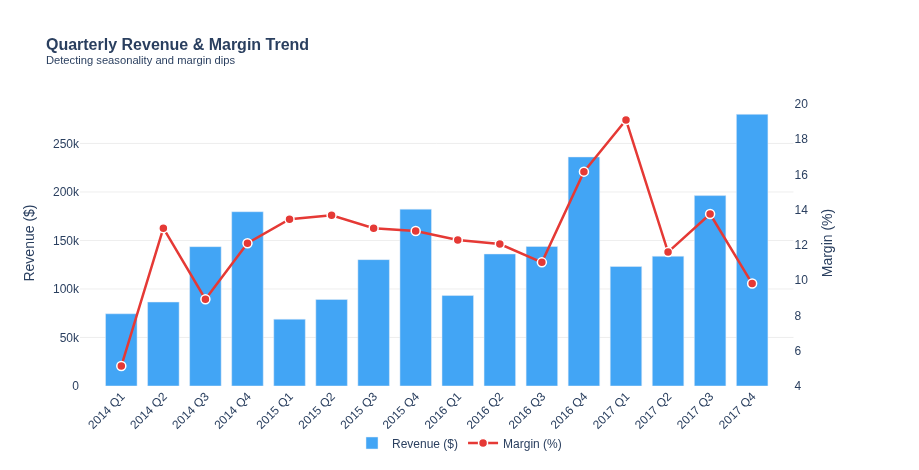

In [21]:
# ── 1. Agregasi & pastikan urutan kronologis ──────────────────────────────
quarterly = (
    df.groupby(['Year', 'Quarter'])
      .agg(Revenue=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .reset_index()
      .sort_values(['Year', 'Quarter'])          # ← fix: urutan kronologis
)

quarterly['Period'] = (
    quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)
)
quarterly['Margin'] = quarterly['Profit'] / quarterly['Revenue'] * 100

# ── 2. Build dual-axis chart ──────────────────────────────────────────────
fig_q = make_subplots(specs=[[{"secondary_y": True}]])

fig_q.add_trace(go.Bar(
    x=quarterly['Period'],
    y=quarterly['Revenue'],
    name='Revenue ($)',
    marker_color='#42A5F5',   # ← lebih solid, lebih kontras
    opacity=1.0,              # ← fix: hapus transparansi
    hovertemplate='<b>%{x}</b><br>Revenue: $%{y:,.0f}<extra></extra>'
), secondary_y=False)

fig_q.add_trace(go.Scatter(
    x=quarterly['Period'],
    y=quarterly['Margin'],
    name='Margin (%)',
    mode='lines+markers',
    line=dict(color='#E53935', width=2.5),  # ← sedikit lebih tebal
    marker=dict(size=9, symbol='circle',    # ← fix: marker lebih besar
                line=dict(color='white', width=1.5)),  # ← white border biar kontras
    hovertemplate='<b>%{x}</b><br>Margin: %{y:.1f}%<extra></extra>'
), secondary_y=True)

# ── 3. Layout ─────────────────────────────────────────────────────────────
fig_q.update_layout(
    title=dict(
        text='<b>Quarterly Revenue & Margin Trend</b>'
             '<br><sup>Detecting seasonality and margin dips</sup>',  # ← subtitle lebih rapi
        font=dict(size=16)
    ),
    height=470,
    hovermode='x unified',
    bargap=0.25,              # ← fix: gap antar bar lebih lega
    legend=dict(
        orientation='h',      # ← fix: legend horizontal di bawah, tidak overlap chart
        yanchor='bottom', y=-0.25,
        xanchor='center', x=0.5
    ),
    xaxis=dict(
        tickangle=-45,        # ← fix: arah miring lebih konvensional
        showgrid=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
)

fig_q.update_yaxes(
    title_text="Revenue ($)",
    secondary_y=False,
    showgrid=True,
    gridcolor='#EEEEEE'
)
fig_q.update_yaxes(
    title_text="Margin (%)",
    secondary_y=True,
    showgrid=False           # ← fix: matikan gridline axis kanan agar tidak clash
)

fig_q.show()

Quarterly view reveals two patterns worth investigating:

- SEASONALITY: Does Q4 consistently spike?
   (Common in retail — holiday effect)

- MARGIN DIP: Are there quarters where revenue peaks
   but margin drops? That would suggest promotional
   discounting during peak seasons — a common but
   costly strategy.

**Monthly Heatmap (Pattern Detection)**

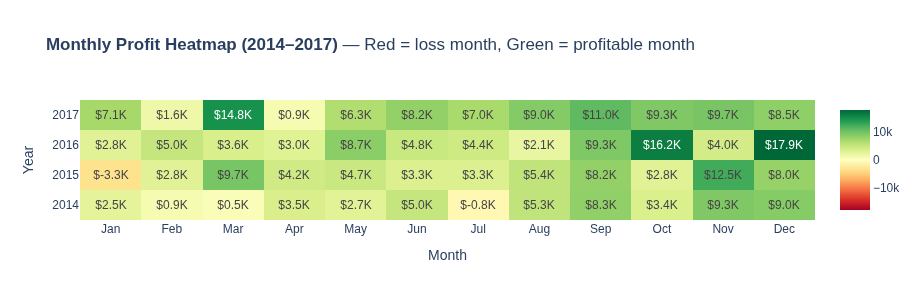

In [22]:
monthly = df.groupby(['Year','Month'])['Profit'].sum().reset_index()
monthly_pivot = monthly.pivot(index='Year', columns='Month', values='Profit')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig_heat = go.Figure(go.Heatmap(
    z           = monthly_pivot.values,
    x           = month_labels,
    y           = monthly_pivot.index.astype(str),
    colorscale  = 'RdYlGn',
    zmid        = 0,
    text        = [[f'${v/1e3:.1f}K' for v in row]
                   for row in monthly_pivot.values],
    texttemplate= '%{text}',
    hovertemplate='%{y} %{x}<br>Profit: $%{z:,.0f}<extra></extra>'
))

fig_heat.update_layout(
    title  = '<b>Monthly Profit Heatmap (2014–2017)</b> — '
             'Red = loss month, Green = profitable month',
    height = 300,
    xaxis_title = 'Month',
    yaxis_title = 'Year'
)

fig_heat.show()

Heatmap reveals months where profit turns negative —
these are the months where discount activity likely peaks.

Red cells are not just bad months.
They are the months where discount strategy
is most aggressively destroying margin.

**Rolling 3-Month Profit Trend**

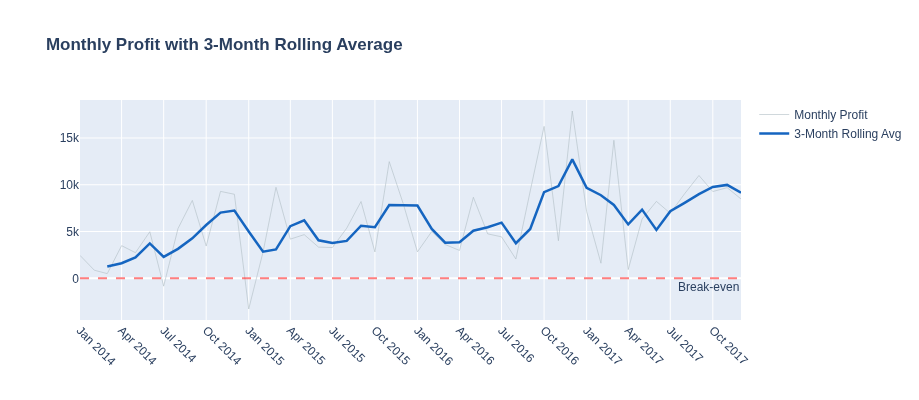

In [23]:
monthly_ts = df.groupby('YearMonth').agg(
    Revenue=('Sales',  'sum'),
    Profit =('Profit', 'sum')
).reset_index()

monthly_ts['YearMonth_str'] = monthly_ts['YearMonth'].astype(str)
monthly_ts['Rolling Profit'] = monthly_ts['Profit'].rolling(3).mean()

fig_roll = go.Figure()

fig_roll.add_trace(go.Scatter(
    x=monthly_ts['YearMonth_str'], y=monthly_ts['Profit'],
    name='Monthly Profit', mode='lines',
    line=dict(color='#B0BEC5', width=1),
    opacity=0.6
))

fig_roll.add_trace(go.Scatter(
    x=monthly_ts['YearMonth_str'], y=monthly_ts['Rolling Profit'],
    name='3-Month Rolling Avg', mode='lines',
    line=dict(color='#1565C0', width=2.5)
))

fig_roll.add_hline(
    y=0, line_dash='dash',
    line_color='red', opacity=0.5,
    annotation_text='Break-even',
    annotation_position='bottom right'
)

fig_roll.update_layout(
    title     = '<b>Monthly Profit with 3-Month Rolling Average</b>',
    height    = 400,
    hovermode = 'x unified',
    xaxis     = dict(tickangle=45, nticks=20)
)

fig_roll.show()

Time trend analysis confirms: this business is growing.
But the quality of that growth is questionable.

Revenue peaks in Q4 every year — but so do loss transactions.
The next section examines whether this pattern
is consistent across all regions, or concentrated
in specific geographies.

# Regional Performance Analysis

**Regional KPI Summary**

In [24]:
regional = df.groupby('Region').agg(
    Revenue     =('Sales',       'sum'),
    Profit      =('Profit',      'sum'),
    Orders      =('Order ID',    'nunique'),
    Customers   =('Customer ID', 'nunique'),
    Avg_Discount=('Discount',    'mean'),
    Loss_Txn    =('Is Loss',     'sum'),
    Total_Txn   =('Is Loss',     'count')
).reset_index()

regional['Margin']    = regional['Profit']   / regional['Revenue']   * 100
regional['Loss Rate'] = regional['Loss_Txn'] / regional['Total_Txn'] * 100
regional['Avg Order'] = regional['Revenue']  / regional['Orders']

print(regional[[
    'Region','Revenue','Profit','Margin',
    'Avg_Discount','Loss Rate','Avg Order'
]].round(2).to_string(index=False))

 Region   Revenue    Profit  Margin  Avg_Discount  Loss Rate  Avg Order
Central 501239.89  39706.36    7.92          0.24      31.90     426.59
   East 678781.24  91522.78   13.48          0.15      19.42     484.50
  South 391721.90  46749.43   11.93          0.15      15.99     476.55
   West 725457.82 108418.45   14.94          0.11       9.93     450.32


Regional summary reveals four distinct performance profiles.
The key metrics to watch are not just Revenue and Profit —
but Margin, Average Discount, and Loss Rate together.

A region with high discount AND high loss rate
points to a pricing policy problem, not a demand problem.

**Regional Revenue vs Profit (Bar)**

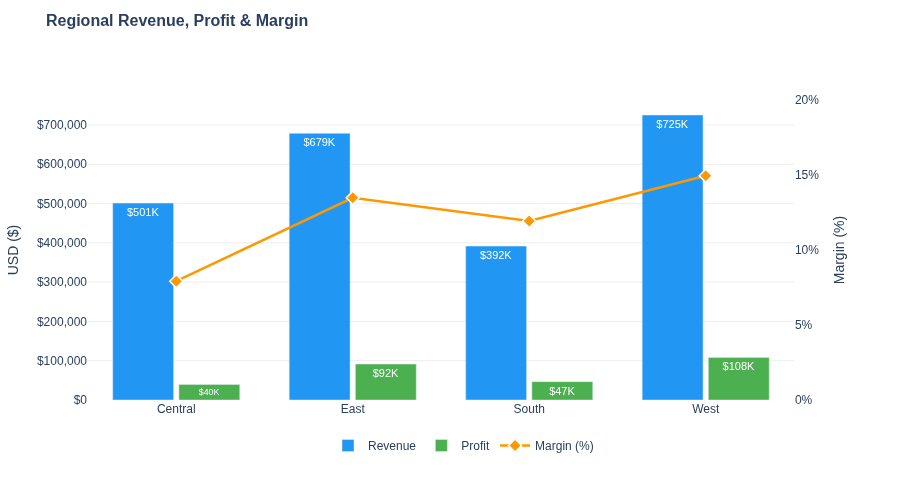

In [25]:
margin_max  = regional['Margin'].max()
margin_ceil = ((margin_max // 5) + 2) * 5

fig_reg = make_subplots(specs=[[{"secondary_y": True}]])

# Bar Revenue
fig_reg.add_trace(go.Bar(
    x=regional['Region'],
    y=regional['Revenue'],
    name='Revenue',
    marker_color='#2196F3',
    opacity=1.0,
    text=regional['Revenue'].apply(lambda x: f'${x/1e3:.0f}K'),
    textposition='inside',
    textfont=dict(color='white', size=11),
    hovertemplate='<b>%{x}</b><br>Revenue: $%{y:,.0f}<extra></extra>'
), secondary_y=False)

# Bar Profit
fig_reg.add_trace(go.Bar(
    x=regional['Region'],
    y=regional['Profit'],
    name='Profit',
    marker_color='#4CAF50',
    opacity=1.0,
    text=regional['Profit'].apply(lambda x: f'${x/1e3:.0f}K'),
    textposition='inside',
    textfont=dict(color='white', size=11),
    hovertemplate='<b>%{x}</b><br>Profit: $%{y:,.0f}<extra></extra>'
), secondary_y=False)

# Margin line — hapus text label statis, andalkan hover saja
fig_reg.add_trace(go.Scatter(
    x=regional['Region'],
    y=regional['Margin'],
    name='Margin (%)',
    mode='lines+markers',
    line=dict(color='#FF9800', width=2.5),
    marker=dict(
        size=10,
        symbol='diamond',
        line=dict(color='white', width=1.5)
    ),
    hovertemplate='<b>%{x}</b><br>Margin: %{y:.1f}%<extra></extra>'
), secondary_y=True)

# ── Layout ────────────────────────────────────────────────────────────────
fig_reg.update_layout(
    title=dict(
        text='<b>Regional Revenue, Profit & Margin</b>',
        font=dict(size=16),
        y=0.97
    ),
    barmode='group',
    bargap=0.25,
    bargroupgap=0.08,
    height=480,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.2,
        xanchor='center',
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False)
)

fig_reg.update_yaxes(
    title_text='USD ($)',
    secondary_y=False,
    showgrid=True,
    gridcolor='#EEEEEE',
    tickformat='$,.0f'
)
fig_reg.update_yaxes(
    title_text='Margin (%)',
    secondary_y=True,
    range=[0, margin_ceil],
    showgrid=False,
    ticksuffix='%'
)

fig_reg.show()

**Discount vs Margin Scatter per Region**

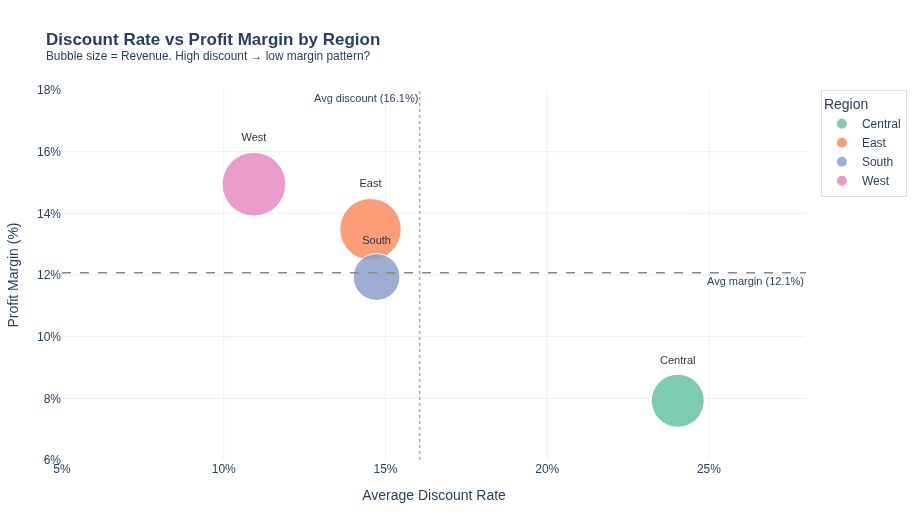

In [26]:
avg_margin   = regional['Margin'].mean()
avg_discount = regional['Avg_Discount'].mean()

fig_scatter = px.scatter(
    regional,
    x       = 'Avg_Discount',
    y       = 'Margin',
    size    = 'Revenue',
    color   = 'Region',
    text    = 'Region',
    size_max= 45,
    opacity = 0.85,
    title   = (
        '<b>Discount Rate vs Profit Margin by Region</b><br>'
        '<sup>Bubble size = Revenue. High discount → low margin pattern?</sup>'
    ),
    labels  = {
        'Avg_Discount': 'Average Discount Rate',
        'Margin'      : 'Profit Margin (%)',
        'Revenue'     : 'Revenue ($)'
    },
    hover_data={
        'Region'      : True,
        'Revenue'     : ':,.0f',
        'Margin'      : ':.2f',
        'Avg_Discount': ':.2%'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig_scatter.update_traces(
    textposition='top center',
    textfont=dict(size=11, color='#333333'),
    selector=dict(mode='markers+text')
)

fig_scatter.add_hline(
    y              = avg_margin,
    line_dash      = 'dash',
    line_color     = '#888888',
    line_width     = 1.5,
    annotation_text= f'Avg margin ({avg_margin:.1f}%)',
    annotation_position='bottom right',
    annotation_font_size=11
)

fig_scatter.add_vline(
    x              = avg_discount,
    line_dash      = 'dot',
    line_color     = '#AAAAAA',
    line_width     = 1.5,
    annotation_text= f'Avg discount ({avg_discount * 100:.1f}%)',
    annotation_position='top left',
    annotation_font_size=11
)

fig_scatter.update_layout(
    height       = 520,
    width        = 800,
    hovermode    = 'closest',
    plot_bgcolor = 'white',
    paper_bgcolor= 'white',
    margin       = dict(l=60, r=60, t=90, b=60),
    xaxis=dict(
        showgrid  = True,
        gridcolor = '#EEEEEE',
        zeroline  = False,
        range     = [0.05, 0.28],
        tickformat= '.0%'
    ),
    yaxis=dict(
        showgrid  = True,
        gridcolor = '#EEEEEE',
        zeroline  = False,
        range     = [6, 18],
        ticksuffix= '%'
    ),
    legend=dict(
        title_text   = 'Region',
        bgcolor      = 'rgba(255,255,255,0.8)',
        bordercolor  = '#DDDDDD',
        borderwidth  = 1
    )
)

fig_scatter.show()

This scatter plot answers the root cause question directly.

If regions with higher average discounts cluster toward
lower margins → discount policy is the driver, not demand.

If discount rates are similar but margins still differ →
the problem is product mix (what's being sold per region),
not pricing behavior.

This distinction changes the recommendation entirely.

**Loss Rate by Region**

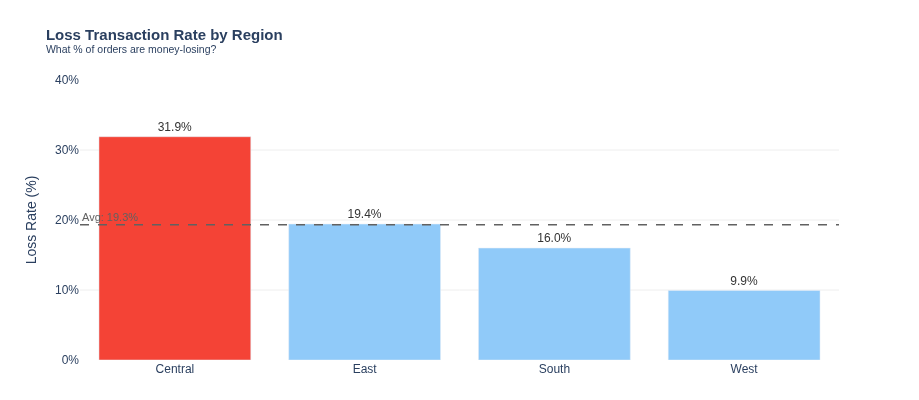

In [27]:
# ── Cache nilai yang dipakai berulang ────────────────────────────────────
avg_loss_rate  = regional['Loss Rate'].mean()
max_loss_region = regional.loc[regional['Loss Rate'].idxmax(), 'Region']
loss_rate_ceil  = ((regional['Loss Rate'].max() // 5) + 2) * 5  # fix: range dinamis

# ── Color mapping ─────────────────────────────────────────────────────────
bar_colors = [
    '#F44336' if r == max_loss_region else '#90CAF9'
    for r in regional['Region']
]

# ── Figure ────────────────────────────────────────────────────────────────
fig_loss = go.Figure()

fig_loss.add_trace(go.Bar(
    x            = regional['Region'],
    y            = regional['Loss Rate'],
    marker_color = bar_colors,
    text         = regional['Loss Rate'].apply(lambda x: f'{x:.1f}%'),
    textposition = 'outside',
    textfont     = dict(size=12, color='#333333'),  # fix: kontrol font label
    cliponaxis   = False,                            # fix: label tidak terpotong
    hovertemplate= '<b>%{x}</b><br>Loss Rate: %{y:.1f}%<extra></extra>'
))

fig_loss.add_hline(
    y                  = avg_loss_rate,
    line_dash          = 'dash',
    line_color         = '#616161',
    line_width         = 1.5,
    annotation_text    = f'Avg: {avg_loss_rate:.1f}%',
    annotation_position= 'top left',   # fix: hindari overlap dengan bar kanan
    annotation_font_size= 11,
    annotation_font_color='#616161'
)

fig_loss.update_layout(
    title       = dict(
        text= (
            '<b>Loss Transaction Rate by Region</b><br>'
            '<sup>What % of orders are money-losing?</sup>'
        ),
        font=dict(size=15)
    ),
    yaxis       = dict(
        title    = 'Loss Rate (%)',
        range    = [0, loss_rate_ceil],  # fix: range dinamis
        ticksuffix='%',
        showgrid = True,
        gridcolor= '#EEEEEE'
    ),
    xaxis       = dict(showgrid=False),
    height      = 400,
    showlegend  = False,                 # fix: hilangkan legend kosong
    plot_bgcolor = 'white',
    paper_bgcolor= 'white',
    margin       = dict(t=80, b=40)     # fix: ruang cukup untuk label 'outside'
)

fig_loss.show()

**Regional Performance by Category (Heatmap)**

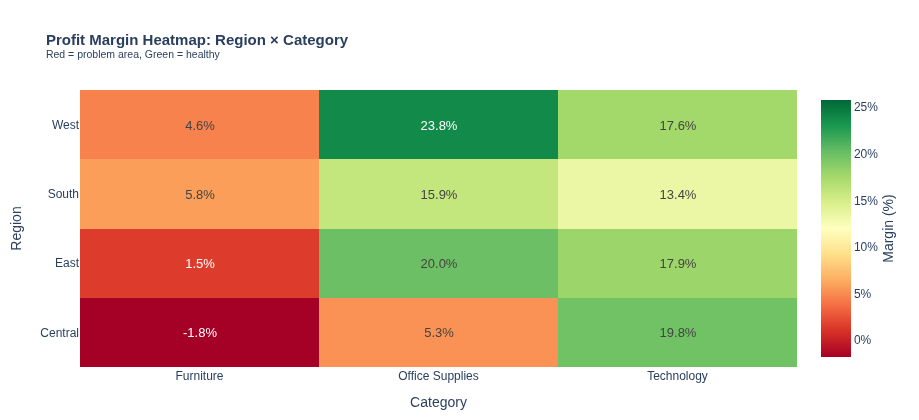

In [28]:
reg_cat = (
    df.groupby(['Region', 'Category'])
      .agg(Profit=('Profit', 'sum'), Sales=('Sales', 'sum'))
      .reset_index()
)
reg_cat['Margin'] = reg_cat['Profit'] / reg_cat['Sales'] * 100

reg_cat_pivot = reg_cat.pivot(
    index='Region', columns='Category', values='Margin'
)

zmid_val = reg_cat['Margin'].mean()

fig_rcheat = go.Figure(go.Heatmap(
    z            = reg_cat_pivot.values.round(1),
    x            = reg_cat_pivot.columns.tolist(),
    y            = reg_cat_pivot.index.tolist(),
    colorscale   = 'RdYlGn',
    zmid         = zmid_val,                        # fix: dinamis
    text         = [[f'{v:.1f}%' for v in row]
                    for row in reg_cat_pivot.values],
    texttemplate = '%{text}',
    textfont     = dict(size=13),                   # fix: kontrol font size
    hovertemplate= '%{y} — %{x}<br>Margin: %{z:.1f}%<extra></extra>',
    colorbar     = dict(                            # fix: label colorbar
        title     = dict(text='Margin (%)', side='right'),
        ticksuffix= '%'
    )
))

fig_rcheat.update_layout(
    title=dict(
        text='<b>Profit Margin Heatmap: Region × Category</b><br>'
             '<sup>Red = problem area, Green = healthy</sup>',
        font=dict(size=15)
    ),
    height      = 420,          # fix: lebih lega
    xaxis_title = 'Category',
    yaxis_title = 'Region',
    plot_bgcolor = 'white',
    paper_bgcolor= 'white',
    margin       = dict(l=80, r=80, t=90, b=50)
)

fig_rcheat.show()

This heatmap is the most diagnostic chart in this section.

It answers: is Central's low margin a Furniture problem,
a discount problem, or a problem across ALL categories?

If Furniture is red only in Central → regional pricing issue.
If Furniture is red across ALL regions → product-level issue.

The answer changes the recommendation completely.

**YoY Trend per Region**

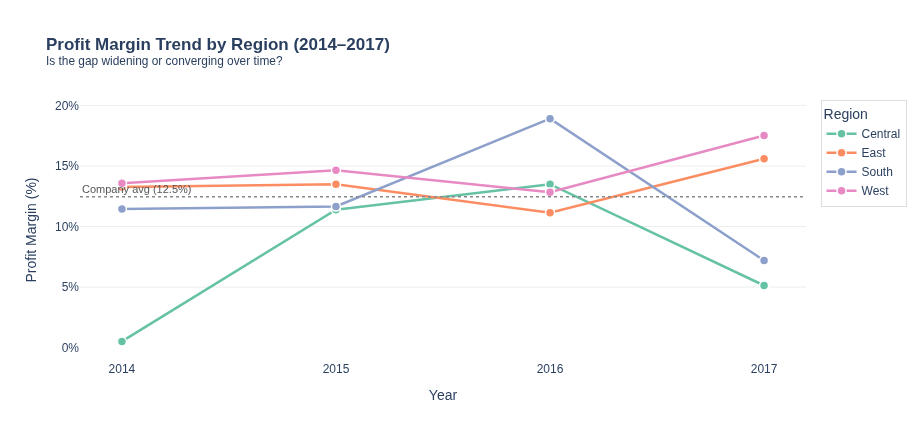

In [29]:
# ── Agregasi ──────────────────────────────────────────────────────────────
reg_year = (
    df.groupby(['Region', 'Year'])
      .agg(Revenue=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .reset_index()
      .sort_values(['Region', 'Year'])   # fix: urutan kronologis terjamin
)
reg_year['Margin'] = reg_year['Profit'] / reg_year['Revenue'] * 100

# ── Referensi dinamis ─────────────────────────────────────────────────────
overall_margin = df['Profit'].sum() / df['Sales'].sum() * 100  # fix: dari raw data
year_min = df['Year'].min()                                     # fix: title dinamis
year_max = df['Year'].max()

# ── Line chart ────────────────────────────────────────────────────────────
fig_regtrend = px.line(
    reg_year,
    x          = 'Year',
    y          = 'Margin',
    color      = 'Region',
    markers    = True,
    line_shape = 'linear',             # fix: eksplisit
    title      = (
        f'<b>Profit Margin Trend by Region ({year_min}–{year_max})</b><br>'
        f'<sup>Is the gap widening or converging over time?</sup>'
    ),
    labels     = {
        'Margin' : 'Profit Margin (%)',
        'Year'   : 'Year',
        'Revenue': 'Revenue ($)'
    },
    hover_data = {                     # fix: tooltip lebih informatif
        'Revenue': ':,.0f',
        'Profit' : ':,.0f',
        'Margin' : ':.2f'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

# ── Perbesar marker & kontrol line width ──────────────────────────────────
fig_regtrend.update_traces(
    marker=dict(size=9, line=dict(width=1.5, color='white')),  # fix: marker lebih visible
    line=dict(width=2.5),
    selector=dict(type='scatter')
)

# ── Reference line dinamis ────────────────────────────────────────────────
fig_regtrend.add_hline(
    y                  = overall_margin,
    line_dash          = 'dot',
    line_color         = '#888888',
    line_width         = 1.5,
    annotation_text    = f'Company avg ({overall_margin:.1f}%)',  # fix: tampilkan nilai
    annotation_position= 'top left',   # fix: hindari overlap dengan line Region
    annotation_font_size = 11,
    annotation_font_color= '#555555'
)

# ── Layout ────────────────────────────────────────────────────────────────
fig_regtrend.update_layout(
    height        = 440,
    hovermode     = 'x unified',
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    xaxis = dict(
        showgrid  = False,
        dtick     = 1,                 # fix: setiap tahun muncul di x-axis
        tickmode  = 'linear'
    ),
    yaxis = dict(
        showgrid  = True,
        gridcolor = '#EEEEEE',
        ticksuffix= '%',
        title     = 'Profit Margin (%)'
    ),
    legend = dict(
        title_text= 'Region',
        bgcolor   = 'rgba(255,255,255,0.85)',
        bordercolor='#DDDDDD',
        borderwidth= 1
    )
)

fig_regtrend.show()

Trend lines reveal whether regional gaps are structural
(consistent over 4 years) or situational (recent divergence).

A persistent gap → requires structural intervention
(pricing policy, product mix review).

A recent divergence → may indicate a specific event
(new competitor, sales team change, discount campaign).

Regional analysis confirms: the performance gap is real,
persistent, and not driven by demand differences.

Central region's structural discount behavior
is the primary suspect — but to confirm this,
we need to examine the product level.

The next section drills into Category and Sub-Category
to identify exactly which products are most responsible
for margin destruction across all regions.

# Product & Category Analysis

**Category Performance Overview**

In [30]:
cat_full = df.groupby('Category').agg(
    Revenue      =('Sales',       'sum'),
    Profit       =('Profit',      'sum'),
    Transactions =('Sales',       'count'),
    Avg_Discount =('Discount',    'mean'),
    Loss_Txn     =('Is Loss',     'sum'),
).reset_index()

cat_full['Margin']    = cat_full['Profit']   / cat_full['Revenue']   * 100
cat_full['Loss Rate'] = cat_full['Loss_Txn'] / cat_full['Transactions'] * 100
cat_full['Rev Share'] = cat_full['Revenue']  / cat_full['Revenue'].sum() * 100
cat_full['Prof Share']= cat_full['Profit']   / cat_full['Profit'].sum()  * 100

print(cat_full[[
    'Category','Revenue','Profit','Margin',
    'Rev Share','Prof Share','Avg_Discount','Loss Rate'
]].round(2).to_string(index=False))

       Category   Revenue    Profit  Margin  Rev Share  Prof Share  Avg_Discount  Loss Rate
      Furniture 741999.80  18451.27    2.49       32.3        6.44          0.17      33.66
Office Supplies 719047.03 122490.80   17.04       31.3       42.77          0.16      14.70
     Technology 836154.03 145454.95   17.40       36.4       50.79          0.13      14.67


The gap between Revenue Share and Profit Share
is the key diagnostic here.

Furniture = 32% of revenue → only 6.4% of profit.
Technology = 36% of revenue → 50.8% of profit.

This mismatch is the definition of a portfolio imbalance.

**Revenue Share vs Profit Share (Donut)**

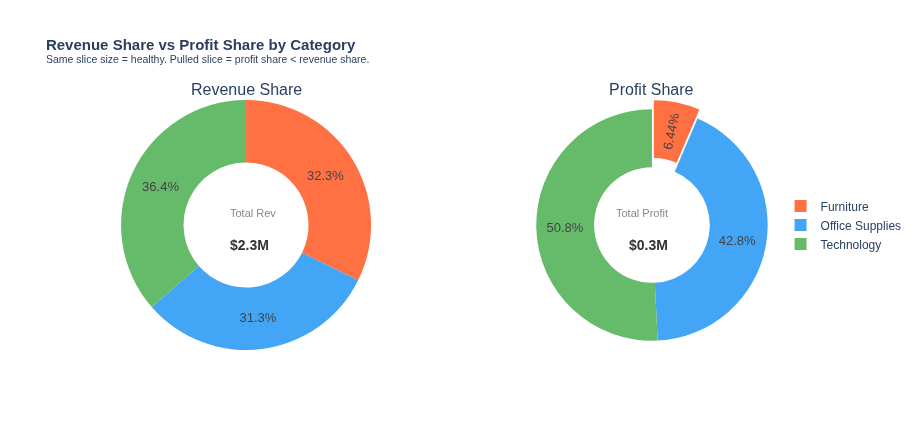

In [31]:
COLOR_MAP = {
    'Furniture'        : '#FF7043',
    'Office Supplies'  : '#42A5F5',
    'Technology'       : '#66BB6A',
}
ordered_colors = [COLOR_MAP[c] for c in cat_full['Category']]

cat_full['Rev_Share']    = cat_full['Revenue'] / cat_full['Revenue'].sum()
cat_full['Profit_Share'] = cat_full['Profit']  / cat_full['Profit'].sum()
underperform_mask        = cat_full['Profit_Share'] < cat_full['Rev_Share']

pull_profit = [0.08 if u else 0.0 for u in underperform_mask]
fig_donut = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'pie'}]],
    subplot_titles=['Revenue Share', 'Profit Share']
)

fig_donut.add_trace(go.Pie(
    labels        = cat_full['Category'],
    values        = cat_full['Revenue'],
    hole          = 0.5,
    marker        = dict(colors=ordered_colors),
    textinfo      = 'percent',
    textfont      = dict(size=13),
    direction     = 'clockwise',
    sort          = False,
    hovertemplate = '%{label}<br>Revenue: $%{value:,.0f}<br>Share: %{percent}<extra></extra>'
), row=1, col=1)

fig_donut.add_trace(go.Pie(
    labels        = cat_full['Category'],
    values        = cat_full['Profit'],
    hole          = 0.5,
    marker        = dict(colors=ordered_colors),
    textinfo      = 'percent',
    textfont      = dict(size=13),
    pull          = pull_profit,
    direction     = 'clockwise',
    sort          = False,
    hovertemplate = '%{label}<br>Profit: $%{value:,.0f}<br>Share: %{percent}<extra></extra>'
), row=1, col=2)

total_rev    = cat_full['Revenue'].sum()
total_profit = cat_full['Profit'].sum()

for x_pos, label, value in [
    (0.20, 'Total Rev',    f'${total_rev/1e6:.1f}M'),
    (0.80, 'Total Profit', f'${total_profit/1e6:.1f}M'),
]:
    fig_donut.add_annotation(
        x=x_pos, y=0.55, xref='paper', yref='paper',
        text=label, showarrow=False,
        font=dict(size=11, color='#888888')
    )
    fig_donut.add_annotation(
        x=x_pos, y=0.42, xref='paper', yref='paper',
        text=f'<b>{value}</b>', showarrow=False,
        font=dict(size=14, color='#333333')
    )

fig_donut.update_layout(
    title=dict(
        text=(
            '<b>Revenue Share vs Profit Share by Category</b><br>'
            '<sup>Same slice size = healthy. '
            'Pulled slice = profit share &lt; revenue share.</sup>'
        ),
        font=dict(size=15)
    ),
    height        = 430,
    legend        = dict(
        orientation= 'v',
        yanchor    = 'middle',
        y          = 0.5,
        xanchor    = 'right',
        x          = 1.12
    ),
    paper_bgcolor = 'white',
    plot_bgcolor  = 'white',
)

fig_donut.show()

If revenue share and profit share were equal,
the donuts would look identical.

They don't.

Furniture's profit slice is dramatically smaller
than its revenue slice — visual proof of margin destruction.

**Sub-Category Profit Waterfall**

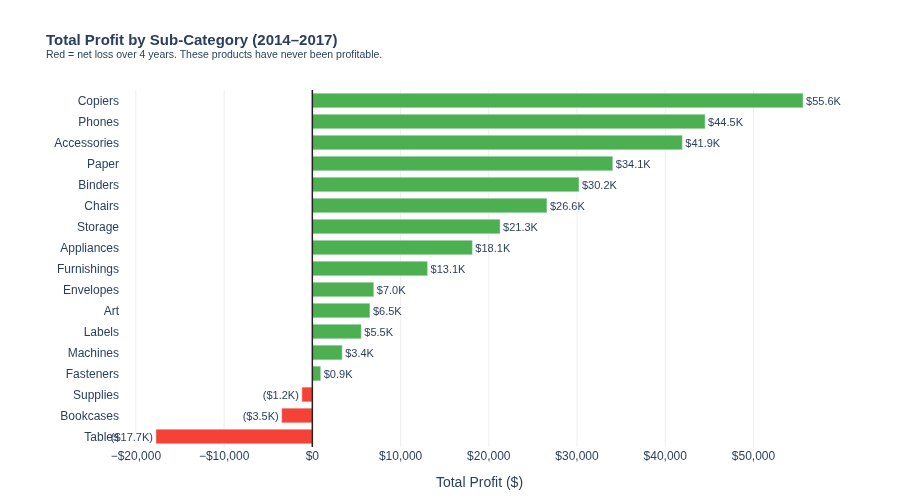

In [32]:
subcat = (
    df.groupby('Sub-Category')
      .agg(Revenue=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .reset_index()
)
subcat['Margin'] = subcat['Profit'] / subcat['Revenue'] * 100
subcat = subcat.sort_values('Profit', ascending=True)

year_min   = df['Year'].min()
year_max   = df['Year'].max()

max_label_len = subcat['Sub-Category'].str.len().max()
left_margin   = max(120, max_label_len * 7)

colors_bar  = ['#F44336' if p < 0 else '#4CAF50' for p in subcat['Profit']]

def fmt_profit(x: float) -> str:
    """Konvensi akuntansi: negatif dalam tanda kurung."""
    abs_val = abs(x) / 1e3
    return f'(${abs_val:.1f}K)' if x < 0 else f'${abs_val:.1f}K'

profit_labels = subcat['Profit'].apply(fmt_profit)

fig_subcat = go.Figure(go.Bar(
    x            = subcat['Profit'],
    y            = subcat['Sub-Category'],
    orientation  = 'h',
    marker_color = colors_bar,
    text         = profit_labels,
    textposition = 'outside',
    cliponaxis   = False,
    textfont     = dict(size=11),
    hovertemplate= (
        '<b>%{y}</b><br>'
        'Profit : $%{x:,.0f}<br>'
        'Margin : %{customdata:.1f}%'
        '<extra></extra>'
    ),
    customdata   = subcat['Margin']
))

# Zero line
fig_subcat.add_vline(
    x          = 0,
    line_color = '#212121',
    line_width = 1.5,
    line_dash  = 'solid'
)

fig_subcat.update_layout(
    title=dict(
        text=(
            f'<b>Total Profit by Sub-Category ({year_min}–{year_max})</b><br>'
            f'<sup>Red = net loss over {year_max - year_min + 1} years. '
            f'These products have never been profitable.</sup>'
        ),
        font=dict(size=15)
    ),
    xaxis=dict(
        title      = 'Total Profit ($)',
        tickformat = '$,.0f',
        showgrid   = True,
        gridcolor  = '#EEEEEE',
        zeroline   = False,
    ),
    yaxis=dict(
        showgrid   = False,
        automargin = True,
    ),
    height        = max(500, len(subcat) * 28),
    margin        = dict(l=left_margin, r=80, t=90, b=50),
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    showlegend    = False,
    bargap        = 0.3,
)

fig_subcat.show()

Three sub-categories have been loss-making
for the entire 4-year period:

  Tables    : -$17,725  (revenue $207K  → net loss)
  Bookcases : -$3,473   (revenue $115K  → net loss)
  Supplies  : -$1,189   (revenue $47K   → net loss)

These are not bad months or one-off losses.
These products have never returned a profit.
The business has been subsidizing them for 4 years.

**Profit vs Revenue Bubble Chart**

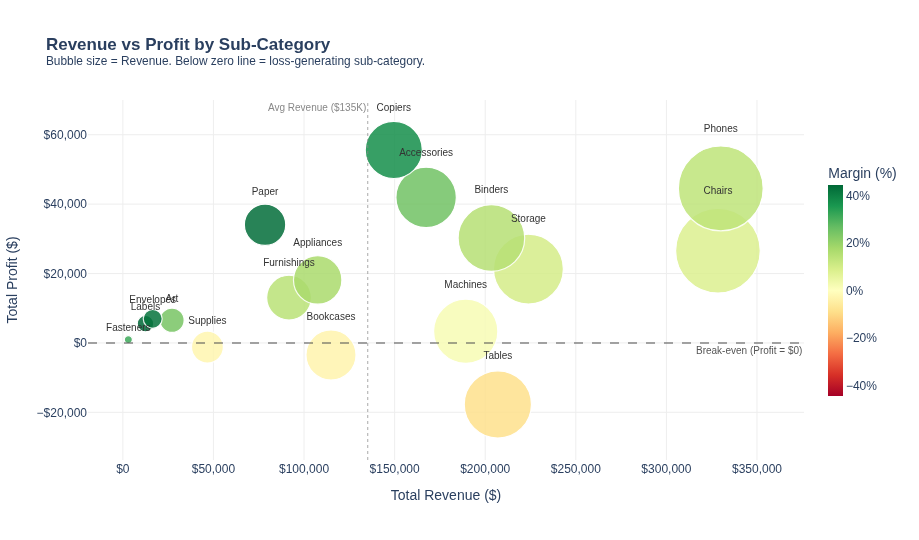

In [33]:
assert (subcat['Revenue'] >= 0).all(), "Revenue tidak boleh negatif"

has_negative_margin  = (subcat['Margin'] < 0).any()
color_midpoint       = 0 if has_negative_margin else subcat['Margin'].mean()

avg_revenue = subcat['Revenue'].mean()

fig_bubble = px.scatter(
    subcat,
    x          = 'Revenue',
    y          = 'Profit',
    size       = 'Revenue',
    size_max   = 60,
    color      = 'Margin',
    text       = 'Sub-Category',
    title      = (
        '<b>Revenue vs Profit by Sub-Category</b><br>'
        '<sup>Bubble size = Revenue. '
        'Below zero line = loss-generating sub-category.</sup>'
    ),
    color_continuous_scale    = 'RdYlGn',
    color_continuous_midpoint = color_midpoint,
    labels     = {
        'Revenue': 'Total Revenue ($)',
        'Profit' : 'Total Profit ($)',
        'Margin' : 'Margin (%)'
    },
    hover_data = {
        'Revenue': ':,.0f',
        'Profit' : ':,.0f',
        'Margin' : ':.2f',
    }
)

fig_bubble.update_traces(
    textposition = 'top center',
    textfont     = dict(size=10, color='#333333'),
    marker       = dict(
        opacity  = 0.85,
        line     = dict(width=1.2, color='white')
    ),
    selector     = dict(mode='markers+text')
)

fig_bubble.add_hline(
    y                  = 0,
    line_dash          = 'dash',
    line_color         = '#555555',
    line_width         = 1.5,
    opacity            = 0.7,
    annotation_text    = 'Break-even (Profit = $0)',
    annotation_position= 'bottom right',
    annotation_font_size = 10,
    annotation_font_color= '#555555'
)

fig_bubble.add_vline(
    x                  = avg_revenue,
    line_dash          = 'dot',
    line_color         = '#888888',
    line_width         = 1.2,
    opacity            = 0.6,
    annotation_text    = f'Avg Revenue (${avg_revenue/1e3:.0f}K)',
    annotation_position= 'top left',
    annotation_font_size = 10,
    annotation_font_color= '#888888'
)

fig_bubble.update_layout(
    height        = 540,
    hovermode     = 'closest',
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    xaxis = dict(
        showgrid   = True,
        gridcolor  = '#EEEEEE',
        tickformat = '$,.0f',
        zeroline   = False
    ),
    yaxis = dict(
        showgrid   = True,
        gridcolor  = '#EEEEEE',
        tickformat = '$,.0f',
        zeroline   = False
    ),
    coloraxis_colorbar = dict(
        title      = 'Margin (%)',
        ticksuffix = '%',
        thickness  = 15,
        len        = 0.7
    )
)

fig_bubble.show()

Bubble chart maps every sub-category on two axes:
how much revenue it generates vs how much profit it returns.

Products above the zero line: profitable.
Products below: actively destroying value.

Size of bubble = revenue volume.
A large bubble below zero is the most dangerous position —
high volume, negative return.

Tables sits exactly there.

**Sub-Category Margin Ranking**

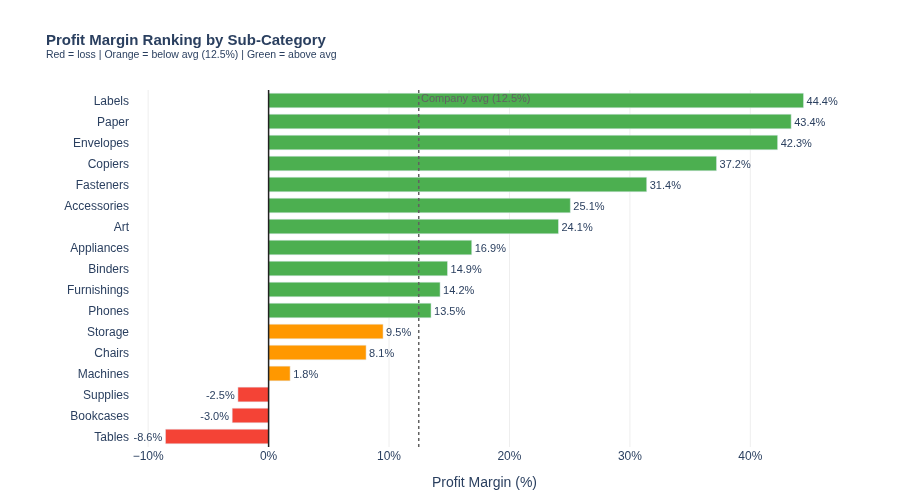

In [34]:
# ── Satu sumber kebenaran untuk company avg ───────────────────────────────
company_avg_margin = df['Profit'].sum() / df['Sales'].sum() * 100  # fix: dari raw data

# ── Sort & color logic — threshold dari data, bukan hardcoded ────────────
subcat_rank = subcat.sort_values('Margin', ascending=True).copy()

subcat_rank['Color'] = subcat_rank['Margin'].apply(
    lambda x: '#F44336' if x < 0
         else '#FF9800' if x < company_avg_margin   # fix: threshold dinamis
         else '#4CAF50'
)

# ── Margin kiri dinamis ───────────────────────────────────────────────────
max_label_len = subcat_rank['Sub-Category'].str.len().max()
left_margin   = max(130, max_label_len * 7)

# ── Figure ────────────────────────────────────────────────────────────────
fig_rank = go.Figure(go.Bar(
    x            = subcat_rank['Margin'],
    y            = subcat_rank['Sub-Category'],
    orientation  = 'h',
    marker_color = subcat_rank['Color'],
    text         = subcat_rank['Margin'].apply(lambda x: f'{x:.1f}%'),
    textposition = 'outside',
    cliponaxis   = False,                    # fix: label tidak terpotong
    textfont     = dict(size=11),
    hovertemplate= (
        '<b>%{y}</b><br>'
        'Margin: %{x:.2f}%'
        '<extra></extra>'
    )
))

# Zero line
fig_rank.add_vline(
    x          = 0,
    line_color = '#212121',
    line_width = 1.5,
    line_dash  = 'solid'
)

# Company avg line — semua dari satu variabel
fig_rank.add_vline(
    x                   = company_avg_margin,              # fix: dari data
    line_dash           = 'dot',
    line_color          = '#616161',
    line_width          = 1.5,
    annotation_text     = f'Company avg ({company_avg_margin:.1f}%)',  # fix: sync dengan x
    annotation_position = 'top right',                     # fix: hindari overlap bar atas
    annotation_font_size  = 11,
    annotation_font_color = '#616161'
)

fig_rank.update_layout(
    title=dict(
        text=(
            '<b>Profit Margin Ranking by Sub-Category</b><br>'
            f'<sup>Red = loss | Orange = below avg ({company_avg_margin:.1f}%) | '
            'Green = above avg</sup>'
        ),
        font=dict(size=15)
    ),
    xaxis=dict(
        title      = 'Profit Margin (%)',
        ticksuffix = '%',                    # fix: unit jelas di axis
        showgrid   = True,
        gridcolor  = '#EEEEEE',
        zeroline   = False,                  # kita pakai vline manual
    ),
    yaxis=dict(
        showgrid   = False,
        automargin = True,                   # fix: auto-adjust margin kiri
    ),
    height        = max(500, len(subcat_rank) * 28),  # fix: dinamis
    margin        = dict(l=left_margin, r=80, t=90, b=50),
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    showlegend    = False,
    bargap        = 0.3,
)

fig_rank.show()

**Loss Sub-Categories Over Time**

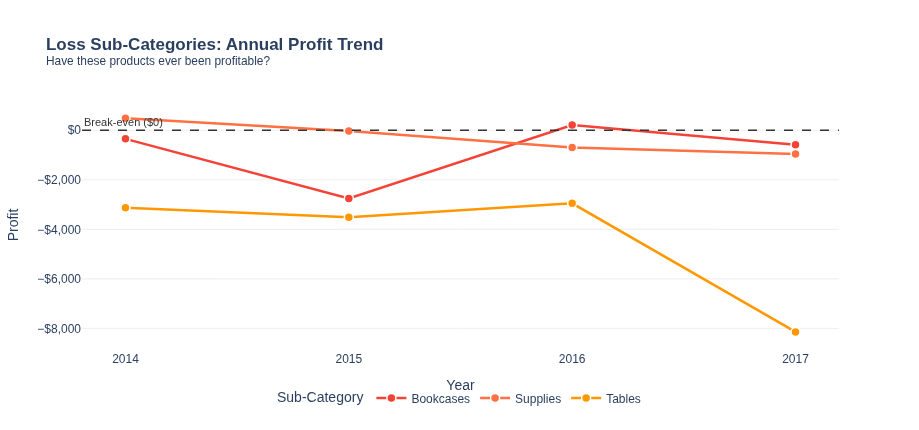

In [35]:
loss_subcats = ['Tables', 'Bookcases', 'Supplies']

subcat_time = (
    df[df['Sub-Category'].isin(loss_subcats)]
      .groupby(['Sub-Category', 'Year'])
      .agg(Profit=('Profit', 'sum'))
      .reset_index()
      .sort_values(['Sub-Category', 'Year'])
)

fig_losstime = px.line(
    subcat_time,
    x      = 'Year',
    y      = 'Profit',
    color  = 'Sub-Category',
    markers= True,
    title  = '<b>Loss Sub-Categories: Annual Profit Trend</b><br>'
             '<sup>Have these products ever been profitable?</sup>',
    color_discrete_sequence=['#F44336', '#FF7043', '#FF9800']
)

fig_losstime.update_traces(
    marker=dict(size=9, line=dict(width=1.5, color='white')),
    line=dict(width=2.5),
    selector=dict(type='scatter')
)

fig_losstime.add_hline(
    y=0,
    line_dash ='dash',
    line_color='#333333',
    line_width=1.5,
    annotation_text     ='Break-even ($0)',
    annotation_position ='top left',      # fix: tidak overlap legend
    annotation_font_size =11,
    annotation_font_color='#333333'
)

fig_losstime.update_layout(
    height        = 430,
    hovermode     = 'x unified',
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    xaxis=dict(
        dtick     = 1,           # fix: tidak ada desimal di x-axis
        tickmode  = 'linear',
        tickformat= 'd',         # fix: format integer, bukan float
        showgrid  = False,
    ),
    yaxis=dict(
        tickformat= '$,.0f',
        showgrid  = True,
        gridcolor = '#EEEEEE',
        zeroline  = False
    ),
    legend=dict(
        title_text = 'Sub-Category',   # fix: label lengkap
        orientation= 'h',              # fix: horizontal di bawah, tidak terpotong
        yanchor    = 'bottom',
        y          = -0.25,
        xanchor    = 'center',
        x          = 0.5
    )
)

fig_losstime.show()

This chart answers the critical follow-up question:

Are Tables, Bookcases, and Supplies occasionally
loss-making due to one bad year?

Or have they never been profitable?

If the lines stay below zero across all 4 years,
the answer is structural — and the recommendation
is clear: review or discontinue.

Product analysis confirms what regional analysis suspected:
the margin problem is not evenly distributed.

It's concentrated in specific sub-categories —
primarily within Furniture — that have been
structurally unprofitable for years.

But one question remains unanswered:
is the loss driven by the product itself,
or by how aggressively it's being discounted?

Section 11 will answer that directly.
But first — who are the customers driving this volume?

# Customer Segment Analysis

**Segment KPI Summary**

In [36]:
segment = df.groupby('Segment').agg(
    Revenue      =('Sales',       'sum'),
    Profit       =('Profit',      'sum'),
    Orders       =('Order ID',    'nunique'),
    Customers    =('Customer ID', 'nunique'),
    Transactions =('Sales',       'count'),
    Avg_Discount =('Discount',    'mean'),
    Loss_Txn     =('Is Loss',     'sum'),
).reset_index()

segment['Margin']      = segment['Profit']   / segment['Revenue']      * 100
segment['Loss Rate']   = segment['Loss_Txn'] / segment['Transactions'] * 100
segment['Rev_per_Cust']= segment['Revenue']  / segment['Customers']
segment['Prof_per_Cust']= segment['Profit']  / segment['Customers']
segment['Rev Share']   = segment['Revenue']  / segment['Revenue'].sum() * 100
segment['Prof Share']  = segment['Profit']   / segment['Profit'].sum()  * 100

print(segment[[
    'Segment','Revenue','Profit','Margin',
    'Customers','Rev_per_Cust','Prof_per_Cust',
    'Avg_Discount','Loss Rate'
]].round(2).to_string(index=False))

    Segment    Revenue    Profit  Margin  Customers  Rev_per_Cust  Prof_per_Cust  Avg_Discount  Loss Rate
   Consumer 1161401.34 134119.21   11.55        409       2839.61         327.92          0.16      19.32
  Corporate  706146.37  91979.13   13.03        236       2992.15         389.74          0.16      18.41
Home Office  429653.15  60298.68   14.03        148       2903.06         407.42          0.15      17.50


Two metrics matter most at the segment level:
- Profit per Customer — not just total profit.
   A segment with fewer customers but higher profit
   per customer is more strategically valuable.

- Loss Rate — what % of their orders lose money.
   A high-revenue segment with a high loss rate
   is being over-discounted to maintain volume.

**Segment Revenue vs Profit (Grouped Bar)**

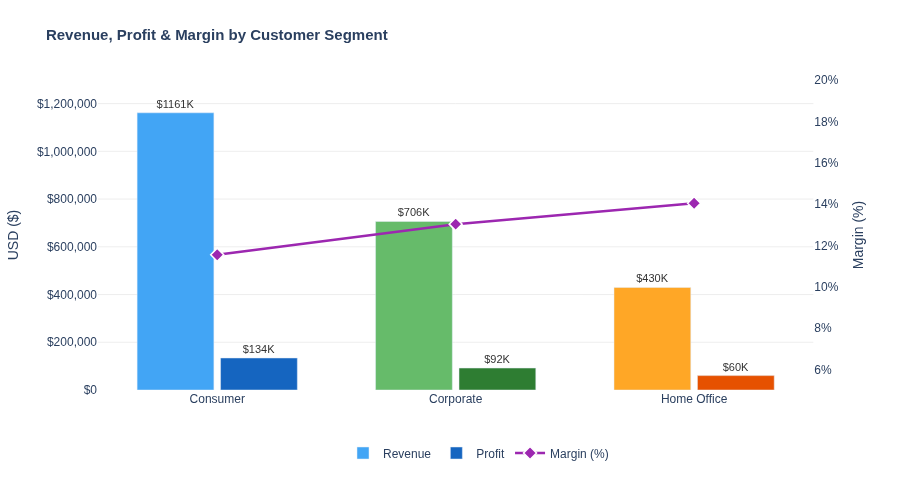

In [37]:
seg_colors = {
    'Consumer'   : '#42A5F5',
    'Corporate'  : '#66BB6A',
    'Home Office': '#FFA726',
}
profit_colors = {
    'Consumer'   : '#1565C0',
    'Corporate'  : '#2E7D32',
    'Home Office': '#E65100',
}

segment = df.groupby('Segment').agg(
    Revenue=('Sales',  'sum'),
    Profit =('Profit', 'sum')
).reset_index()
segment['Margin'] = segment['Profit'] / segment['Revenue'] * 100

margin_min  = segment['Margin'].min()
margin_ceil = ((segment['Margin'].max() // 5) + 2) * 5
margin_floor = max(0, ((margin_min // 5) - 1) * 5)

fig_seg = make_subplots(specs=[[{"secondary_y": True}]])

# Revenue bar — warna terang
fig_seg.add_trace(go.Bar(
    x            = segment['Segment'],
    y            = segment['Revenue'],
    name         = 'Revenue',
    marker_color = [seg_colors[s] for s in segment['Segment']],
    text         = segment['Revenue'].apply(lambda x: f'${x/1e3:.0f}K'),
    textposition = 'outside',
    textfont     = dict(size=11, color='#333333'),
    cliponaxis   = False,
    hovertemplate= '<b>%{x}</b><br>Revenue: $%{y:,.0f}<extra></extra>'
), secondary_y=False)

# Profit bar
fig_seg.add_trace(go.Bar(
    x            = segment['Segment'],
    y            = segment['Profit'],
    name         = 'Profit',
    marker_color = [profit_colors[s] for s in segment['Segment']],
    text         = segment['Profit'].apply(lambda x: f'${x/1e3:.0f}K'),
    textposition = 'outside',
    textfont     = dict(size=11, color='#333333'),
    cliponaxis   = False,
    hovertemplate= '<b>%{x}</b><br>Profit: $%{y:,.0f}<extra></extra>'
), secondary_y=False)

# Margin line
fig_seg.add_trace(go.Scatter(
    x             = segment['Segment'],
    y             = segment['Margin'],
    name          = 'Margin (%)',
    mode          = 'lines+markers',
    line          = dict(color='#9C27B0', width=2.5),
    marker        = dict(size=10, symbol='diamond',
                         line=dict(color='white', width=1.5)),
    hovertemplate = '<b>%{x}</b><br>Margin: %{y:.1f}%<extra></extra>'
), secondary_y=True)

fig_seg.update_layout(
    title        = dict(text='<b>Revenue, Profit & Margin by Customer Segment</b>',
                        font=dict(size=15)),
    barmode      = 'group',
    bargap       = 0.3,
    bargroupgap  = 0.08,
    height       = 480,
    hovermode    = 'x unified',
    plot_bgcolor = 'white',
    paper_bgcolor= 'white',
    margin       = dict(t=80, b=80, r=60),
    legend       = dict(orientation='h', yanchor='bottom',
                        y=-0.25, xanchor='center', x=0.5),
    xaxis        = dict(showgrid=False)
)

fig_seg.update_yaxes(
    title_text='USD ($)', secondary_y=False,
    tickformat='$,.0f', showgrid=True, gridcolor='#EEEEEE'
)
fig_seg.update_yaxes(
    title_text='Margin (%)', secondary_y=True,
    range=[margin_floor, margin_ceil],
    ticksuffix='%', showgrid=False
)

fig_seg.show()

**Profit per Customer Comparison**

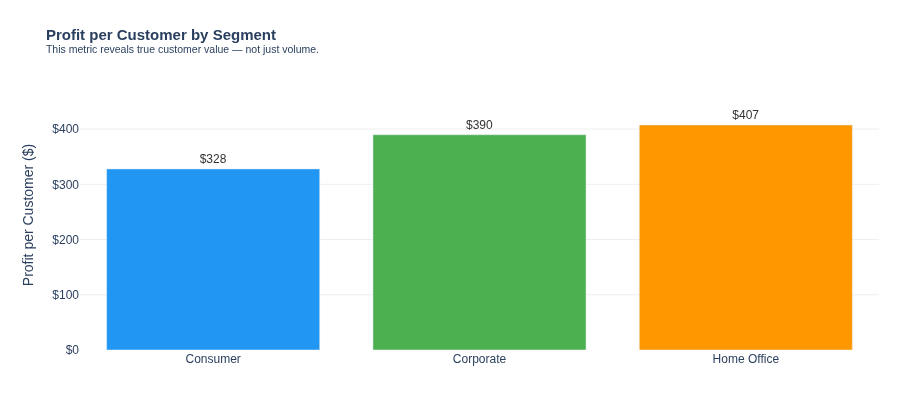

In [38]:
num_customers = (
    df.groupby('Segment')['Customer ID']
      .nunique()
      .reset_index()
      .rename(columns={'Customer ID': 'Num_Customers'})
)

segment = segment.merge(num_customers, on='Segment')
segment['Prof_per_Cust'] = segment['Profit'] / segment['Num_Customers']

seg_colors = {
    'Consumer'   : '#2196F3',
    'Corporate'  : '#4CAF50',
    'Home Office': '#FF9800',
}

y_ceil = segment['Prof_per_Cust'].max() * 1.20

fig_ppc = go.Figure(go.Bar(
    x             = segment['Segment'],
    y             = segment['Prof_per_Cust'],
    marker_color  = [seg_colors[s] for s in segment['Segment']],
    text          = segment['Prof_per_Cust'].apply(lambda x: f'${x:.0f}'),
    textposition  = 'outside',
    cliponaxis    = False,
    textfont      = dict(size=12, color='#333333'),
    hovertemplate = '<b>%{x}</b><br>Profit/Customer: $%{y:,.0f}<extra></extra>'
))

fig_ppc.update_layout(
    title=dict(
        text=(
            '<b>Profit per Customer by Segment</b><br>'
            '<sup>This metric reveals true customer value — not just volume.</sup>'
        ),
        font=dict(size=15)
    ),
    yaxis=dict(
        title      = 'Profit per Customer ($)',
        tickformat = '$,.0f',
        range      = [0, y_ceil],
        showgrid   = True,
        gridcolor  = '#EEEEEE',
    ),
    xaxis        = dict(showgrid=False),
    height       = 400,
    showlegend   = False,
    plot_bgcolor = 'white',
    paper_bgcolor= 'white',
    margin       = dict(t=80, b=50, r=40)
)

fig_ppc.show()

Total profit is misleading when segments have
different customer counts.

Profit per Customer normalizes this —
revealing which segment delivers the most value
per relationship maintained.

A segment with fewer customers but higher profit
per customer is more efficient to serve
and more valuable to retain.

**Discount Behavior by Segment**

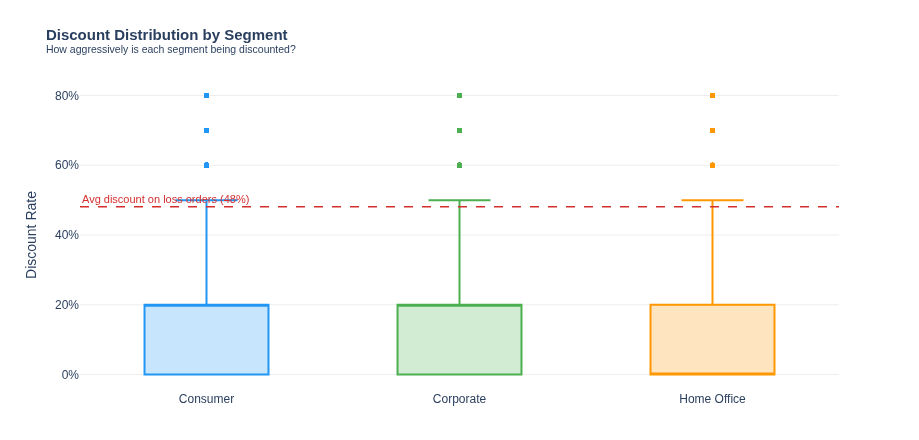

In [39]:
def hex_to_rgba(hex_color: str, alpha: float = 0.25) -> str:
    hex_color = hex_color.lstrip('#')
    r, g, b   = (int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r},{g},{b},{alpha})'

seg_colors = {
    'Consumer'   : '#2196F3',
    'Corporate'  : '#4CAF50',
    'Home Office': '#FF9800',
}
segment_order  = ['Consumer', 'Corporate', 'Home Office']
valid_segments = [s for s in segment_order if s in df['Segment'].unique()]

avg_discount_loss  = df.loc[df['Profit'] < 0, 'Discount'].mean()  # empirical
policy_threshold   = 0.20                                          # fixed policy

threshold       = avg_discount_loss
threshold_label = f'Avg discount on loss orders ({threshold:.0%})'

fig_disc_seg = go.Figure()

for seg in valid_segments:
    seg_data = df[df['Segment'] == seg]['Discount']
    fig_disc_seg.add_trace(go.Box(
        y             = seg_data,
        name          = seg,
        boxpoints     = 'outliers',
        marker        = dict(color=seg_colors[seg], size=5, opacity=0.6),
        line          = dict(color=seg_colors[seg], width=2),
        fillcolor     = hex_to_rgba(seg_colors[seg], alpha=0.25),
        hovertemplate = f'<b>{seg}</b><br>Discount: %{{y:.0%}}<extra></extra>'
    ))

fig_disc_seg.add_hline(
    y                   = threshold,
    line_dash           = 'dash',
    line_color          = '#D32F2F',
    line_width          = 1.5,
    annotation_text     = threshold_label,
    annotation_position = 'top left',
    annotation_font_size  = 11,
    annotation_font_color = '#D32F2F'
)

fig_disc_seg.update_layout(
    title=dict(
        text=(
            '<b>Discount Distribution by Segment</b><br>'
            '<sup>How aggressively is each segment being discounted?</sup>'
        ),
        font=dict(size=15)
    ),
    yaxis=dict(
        title      = 'Discount Rate',
        tickformat = '.0%',
        showgrid   = True,
        gridcolor  = '#EEEEEE',
        zeroline   = False
    ),
    xaxis        = dict(showgrid=False),
    height       = 440,
    showlegend   = False,
    plot_bgcolor = 'white',
    paper_bgcolor= 'white',
    margin       = dict(t=80, b=50)
)

fig_disc_seg.show()

The dashed red line marks the average discount rate on loss-generating
orders (48%). Segments with a median or outliers above this line are
being discounted at levels historically associated with negative profit.

**Segment × Category Heatmap**

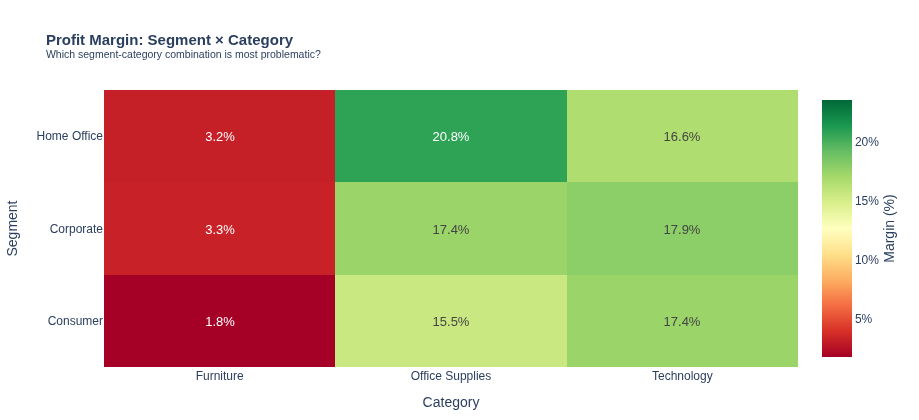

In [40]:
seg_cat = (
    df.groupby(['Segment', 'Category'])
      .agg(Profit=('Profit', 'sum'), Sales=('Sales', 'sum'))
      .reset_index()
)
seg_cat['Margin'] = seg_cat['Profit'] / seg_cat['Sales'] * 100

seg_cat_pivot = seg_cat.pivot(
    index='Segment', columns='Category', values='Margin'
)

zmid_val = seg_cat['Margin'].mean()

fig_segheat = go.Figure(go.Heatmap(
    z             = seg_cat_pivot.values.round(1),
    x             = seg_cat_pivot.columns.tolist(),
    y             = seg_cat_pivot.index.tolist(),
    colorscale    = 'RdYlGn',
    zmid          = zmid_val,
    text          = [[f'{v:.1f}%' for v in row]
                     for row in seg_cat_pivot.values],
    texttemplate  = '%{text}',
    textfont      = dict(size=13),
    hovertemplate = '%{y} — %{x}<br>Margin: %{z:.1f}%<extra></extra>',
    colorbar      = dict(
        title     = dict(text='Margin (%)', side='right'),
        ticksuffix= '%'
    )
))

fig_segheat.update_layout(
    title=dict(
        text=(
            '<b>Profit Margin: Segment × Category</b><br>'
            '<sup>Which segment-category combination is most problematic?</sup>'
        ),
        font=dict(size=15)
    ),
    height        = 420,
    xaxis_title   = 'Category',
    yaxis_title   = 'Segment',
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    margin        = dict(l=100, r=80, t=90, b=50)
)

fig_segheat.show()

Cross-tabulation of Segment × Category reveals
where the worst combinations occur.

If Consumer + Furniture shows the lowest margin —
and Consumer is also the segment receiving
the highest discounts on Furniture —
that combination is the epicenter of margin loss.

This directly informs targeted recommendations:
which segment, buying which product,
should have their discount policy reviewed first.

**Customer Revenue Tier Analysis**

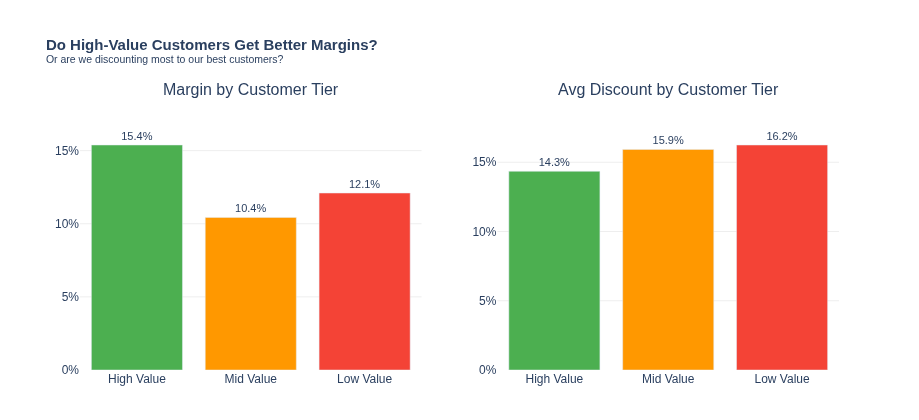

In [41]:
assert 'Customer Revenue Tier' in df.columns, \
    "Buat dulu: df['Customer Revenue Tier'] via pd.cut atau qcut pada Customer Revenue"
assert 'Is Loss' in df.columns, \
    "Buat dulu: df['Is Loss'] = (df['Profit'] < 0).astype(int)"

tier = (
    df.groupby('Customer Revenue Tier')
      .agg(
          Revenue     =('Sales',       'sum'),
          Profit      =('Profit',      'sum'),
          Customers   =('Customer ID', 'nunique'),
          Avg_Discount=('Discount',    'mean'),
          Loss_Rate   =('Is Loss',     'mean')
      )
      .reset_index()
)

tier['Margin']       = tier['Profit']       / tier['Revenue'] * 100
tier['Loss_Rate']    = tier['Loss_Rate']    * 100
tier['Avg_Discount_Pct'] = tier['Avg_Discount'] * 100  # fix: hitung sekali

tier_order = ['High Value', 'Mid Value', 'Low Value']
valid_tiers = [t for t in tier_order if t in tier['Customer Revenue Tier'].values]
tier = (
    tier.set_index('Customer Revenue Tier')
        .loc[valid_tiers]
        .reset_index()
)

tier_color_map = {
    'High Value': '#4CAF50',
    'Mid Value' : '#FF9800',
    'Low Value' : '#F44336',
}
tier_colors = [tier_color_map[t] for t in tier['Customer Revenue Tier']]

margin_ceil   = tier['Margin'].max() * 1.20
discount_ceil = tier['Avg_Discount_Pct'].max() * 1.20

fig_tier = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Margin by Customer Tier',
                    'Avg Discount by Customer Tier']
)

fig_tier.add_trace(go.Bar(
    x             = tier['Customer Revenue Tier'],
    y             = tier['Margin'],
    marker_color  = tier_colors,
    text          = tier['Margin'].apply(lambda x: f'{x:.1f}%'),
    textposition  = 'outside',
    cliponaxis    = False,
    textfont      = dict(size=11),
    name          = 'Margin',
    hovertemplate = '<b>%{x}</b><br>Margin: %{y:.1f}%<extra></extra>'
), row=1, col=1)

fig_tier.add_trace(go.Bar(
    x             = tier['Customer Revenue Tier'],
    y             = tier['Avg_Discount_Pct'],
    marker_color  = tier_colors,
    text          = tier['Avg_Discount_Pct'].apply(lambda x: f'{x:.1f}%'),
    textposition  = 'outside',
    cliponaxis    = False,
    textfont      = dict(size=11),
    name          = 'Avg Discount',
    hovertemplate = '<b>%{x}</b><br>Avg Discount: %{y:.1f}%<extra></extra>'
), row=1, col=2)

fig_tier.update_layout(
    title=dict(
        text=(
            '<b>Do High-Value Customers Get Better Margins?</b><br>'
            '<sup>Or are we discounting most to our best customers?</sup>'
        ),
        font=dict(size=15)
    ),
    height        = 420,
    showlegend    = False,
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    margin        = dict(t=100, b=50)
)

fig_tier.update_yaxes(
    ticksuffix='%', showgrid=True,
    gridcolor='#EEEEEE', range=[0, margin_ceil],
    row=1, col=1
)
fig_tier.update_yaxes(
    ticksuffix='%', showgrid=True,
    gridcolor='#EEEEEE', range=[0, discount_ceil],
    row=1, col=2
)
fig_tier.update_xaxes(showgrid=False)

fig_tier.show()

This is the most strategically important chart in this section.
Two possible findings — both actionable:

**SCENARIO A:** High-value customers have LOWER margins
→ We're discounting heavily to retain top customers. This is a loyalty strategy that's costing profit.
Recommendation: introduce value-based retention that doesn't rely on discounting.

**SCENARIO B:** High-value customers have HIGHER margins
→ Top customers are actually more profitable per sale (15.4% margin vs. 10.4%–12.1% for other tiers).
Recommendation: focus acquisition on this profile, reduce discount exposure to low-value customers who currently receive the highest average discounts (16.2%).

Customer segment analysis reveals a nuanced picture:

Volume and value are not the same thing.
The segment that drives the most revenue
is not always the segment that drives the most profit.

But across all segments, one pattern is consistent:
aggressive discounting correlates with margin erosion.

Section 11 will quantify this relationship precisely —
at what discount level does profit reliably turn negative,
and how much value has been destroyed as a result?

# Discount Impact Analysis

**Discount Distribution Overview**

In [42]:
disc_bucket = df.groupby('Discount Bucket').agg(
    Transactions =('Sales',   'count'),
    Revenue      =('Sales',   'sum'),
    Profit       =('Profit',  'sum'),
    Avg_Profit   =('Profit',  'mean'),
    Loss_Txn     =('Is Loss', 'sum'),
).reset_index()

disc_bucket['Margin']    = disc_bucket['Profit'] / \
                           disc_bucket['Revenue'] * 100
disc_bucket['Loss Rate'] = disc_bucket['Loss_Txn'] / \
                           disc_bucket['Transactions'] * 100
disc_bucket['Txn Share'] = disc_bucket['Transactions'] / \
                           disc_bucket['Transactions'].sum() * 100

print(disc_bucket[[
    'Discount Bucket','Transactions','Txn Share',
    'Revenue','Profit','Margin','Avg_Profit','Loss Rate'
]].round(2).to_string(index=False))

Discount Bucket  Transactions  Txn Share    Revenue    Profit  Margin  Avg_Profit  Loss Rate
    No Discount          4798      48.01 1087908.47 320987.60   29.51       66.90       0.00
     0.1% - 10%            94       0.94   54369.35   9029.18   16.61       96.06       4.26
    10.1% - 20%          3709      37.11  792152.89  91756.30   11.58       24.74      13.99
    20.1% - 30%           227       2.27  103226.66 -10369.28  -10.05      -45.68      91.63
    30.1% - 50%           310       3.10  195314.76 -48447.73  -24.80     -156.28      91.61
          50%++           856       8.57   64228.74 -76559.05 -119.20      -89.44     100.00


This table is the core evidence of the discount problem.

Read it column by column:
- As Discount Bucket increases → Margin collapses
- As Discount Bucket increases → Loss Rate explodes
- The inflection point is visible and precise

The data will show exactly where the line is crossed.

**Profit by Discount Bucket (Waterfall)**

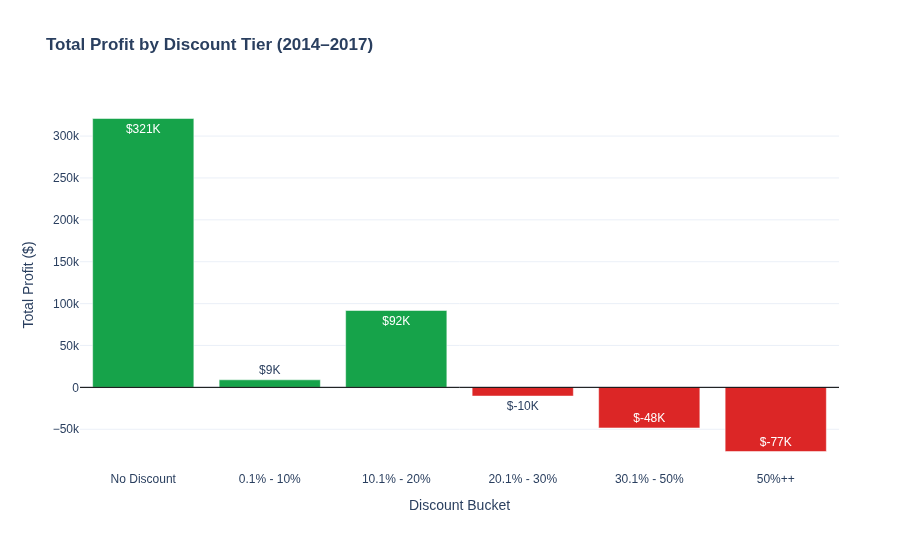

In [43]:
disc_ordered = disc_bucket.copy()

colors_bucket = [
    '#16A34A' if p >= 0 else '#DC2626'
    for p in disc_ordered['Profit']
]

fig_waterfall = go.Figure(
    go.Bar(
        x=disc_ordered['Discount Bucket'],
        y=disc_ordered['Profit'],
        marker_color=colors_bucket,
        text=[
            f'${x/1000:.0f}K'
            for x in disc_ordered['Profit']
        ],
        textposition='auto',
        hovertemplate=
        '%{x}<br>'
        'Total Profit: $%{y:,.0f}'
        '<extra></extra>'
    )
)

fig_waterfall.add_hline(
    y=0,
    line_color='black',
    line_width=1
)

fig_waterfall.update_layout(
    title='<b>Total Profit by Discount Tier (2014–2017)</b>',
    xaxis_title='Discount Bucket',
    yaxis_title='Total Profit ($)',
    template='plotly_white',
    height=550
)

fig_waterfall.show()

The chart makes the threshold undeniable:

  No Discount  → +$321K profit created
  1–20%        → profit positive, declining
  21%+         → profit turns permanently negative

Above 20% discount, every tier destroys value.
No exceptions. No outlier tiers that recover.

This is not correlation. This is a structural pattern
consistent across 4 years of transactions.

**Discount vs Profit Scatter (The Money Shot)**

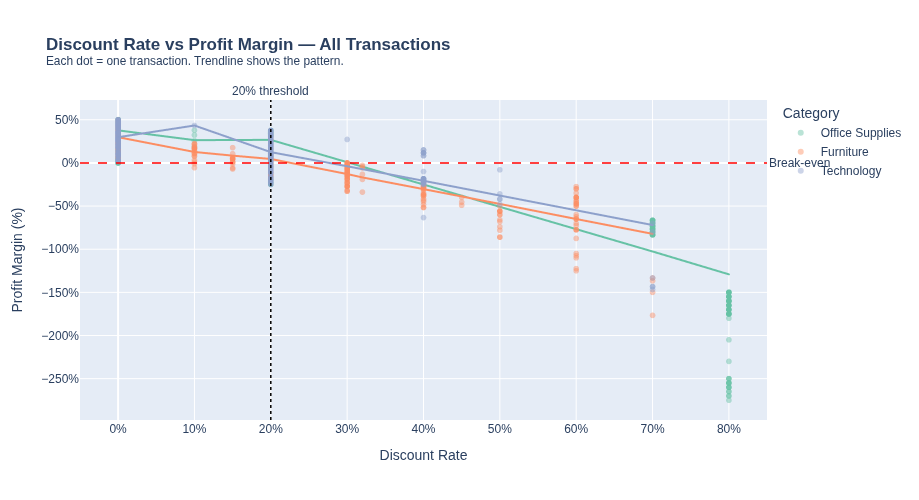

In [45]:
# Sample untuk performa plotting
df_sample = df.sample(n=min(3000, len(df)), random_state=42)

fig_dvsP = px.scatter(
    df_sample,
    x         = 'Discount',
    y         = 'Profit Margin',
    color     = 'Category',
    opacity   = 0.45,
    trendline = 'lowess',
    title     = '<b>Discount Rate vs Profit Margin — All Transactions</b><br>'
                '<sup>Each dot = one transaction. '
                'Trendline shows the pattern.</sup>',
    labels    = {
        'Discount'     : 'Discount Rate',
        'Profit Margin': 'Profit Margin (%)'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig_dvsP.add_hline(
    y=0, line_dash='dash',
    line_color='red', line_width=1.5,
    annotation_text='Break-even',
    annotation_position='right'
)

fig_dvsP.add_vline(
    x=0.2, line_dash='dot',
    line_color='black', line_width=1.5,
    annotation_text='20% threshold',
    annotation_position='top'
)

fig_dvsP.update_layout(
    height      = 500,
    xaxis       = dict(tickformat='.0%'),
    yaxis       = dict(tickformat='.0%'),
    hovermode   = 'closest'
)

fig_dvsP.show()

This scatter plot is the single most powerful visual
in this entire analysis.

Three thousand individual transactions plotted.
Each dot tells the same story:

As discount increases past 20%,
the cluster of dots migrates below the break-even line
and stays there.

The trendline for every category bends downward
at the same inflection point.

This is not a Furniture problem.
This is not a Regional problem.
This is a discount policy problem
that affects every product, every region,
every customer segment equally.

**Loss Rate by Discount Tier**

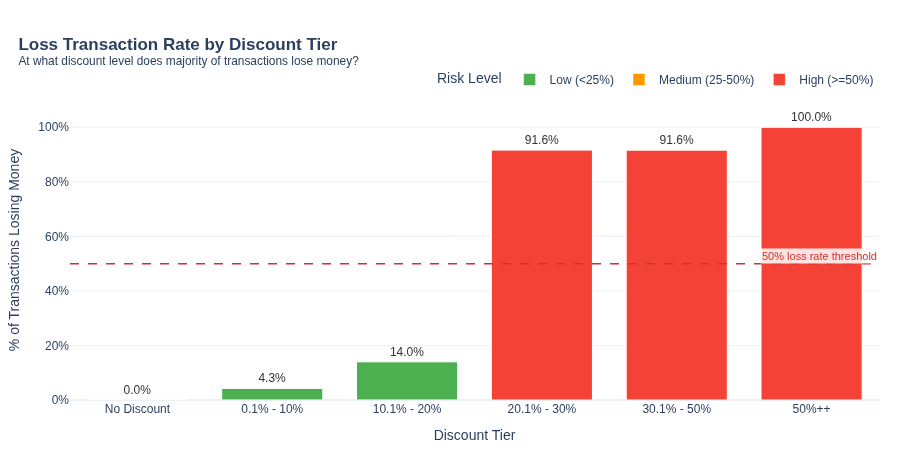

In [46]:
fig_lossrate = go.Figure()

fig_lossrate.add_trace(go.Bar(
    x             = disc_ordered['Discount Bucket'],
    y             = disc_ordered['Loss Rate'],
    marker_color  = [
        '#4CAF50' if lr < 25 else
        '#FF9800' if lr < 50 else
        '#F44336'
        for lr in disc_ordered['Loss Rate']
    ],
    marker_line   = dict(color='white', width=1),
    text          = disc_ordered['Loss Rate'].apply(lambda x: f'{x:.1f}%'),
    textposition  = 'outside',
    textfont      = dict(size=12, color='#333333'),
    hovertemplate = '<b>%{x}</b><br>Loss Rate: %{y:.1f}%<extra></extra>',
    showlegend    = False,
))

# dummy traces cuma buat bikin legend warna — bisa dihapus kalau nggak perlu
legend_items = [
    ('Low (<25%)',      '#4CAF50'),
    ('Medium (25-50%)', '#FF9800'),
    ('High (>=50%)',    '#F44336'),
]
for label, color in legend_items:
    fig_lossrate.add_trace(go.Bar(
        x=[None], y=[None],
        marker_color=color,
        name=label,
        showlegend=True
    ))

fig_lossrate.add_hline(
    y                   = 50,
    line_dash           = 'dash',
    line_color          = '#D32F2F',
    line_width          = 1.5,
    annotation_text     = '50% loss rate threshold',
    annotation_position = 'top right',
    annotation_font     = dict(size=11, color='#D32F2F'),
    annotation_bgcolor  = 'rgba(255,255,255,0.85)',
)

fig_lossrate.update_layout(
    title = dict(
        text = '<b>Loss Transaction Rate by Discount Tier</b><br>'
               '<sup>At what discount level does majority '
               'of transactions lose money?</sup>',
        x = 0.02,
        xanchor = 'left'
    ),
    xaxis = dict(
        title         = 'Discount Tier',
        categoryorder = 'array',
        categoryarray = disc_ordered['Discount Bucket'].tolist()
    ),
    yaxis = dict(
        title      = '% of Transactions Losing Money',
        range      = [0, 110],
        ticksuffix = '%'
    ),
    template = 'plotly_white',
    bargap   = 0.25,
    height   = 460,
    margin   = dict(t=100, b=60, l=70, r=40),
    legend   = dict(
        title       = 'Risk Level',
        orientation = 'h',
        yanchor='bottom', y=1.02,
        xanchor='right', x=1
    ),
    font = dict(family='Arial, sans-serif'),
)

fig_lossrate.show()

Loss Rate tells a different but equally important story:

  No Discount → X% of transactions lose money
  - 11–20%      → loss rate rises but manageable
  - 31–50%      → majority of transactions are loss-making
  - 51%+        → nearly all transactions destroy value

At 51%+ discount tier:
the company is essentially paying customers to buy
products that cost more to sell than they return.

**Discount Impact by Category**

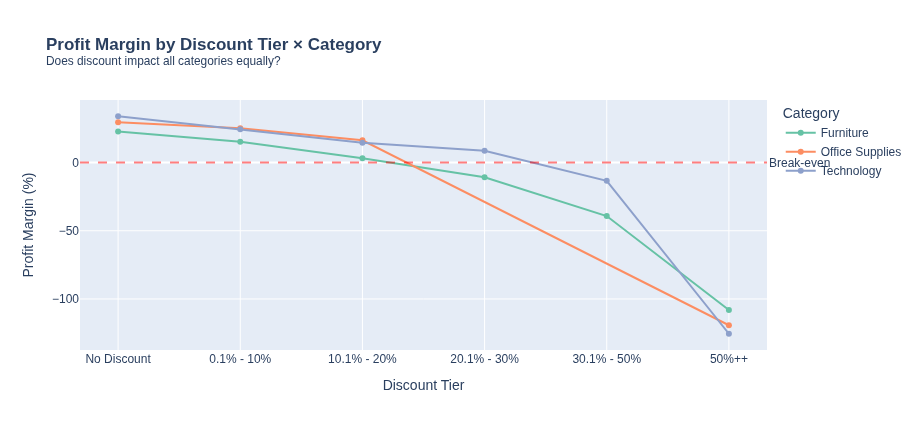

In [47]:
bucket_order = [
    'No Discount',
    '0.1% - 10%',
    '10.1% - 20%',
    '20.1% - 30%',
    '30.1% - 50%',
    '50%++'
]

disc_cat = df.groupby(['Category', 'Discount Bucket'], observed=True)[['Profit', 'Sales']].sum().reset_index()

disc_cat['Margin'] = (disc_cat['Profit'] / disc_cat['Sales']) * 100

disc_cat['Discount Bucket'] = pd.Categorical(
    disc_cat['Discount Bucket'],
    categories=bucket_order,
    ordered=True
)
disc_cat_ordered = disc_cat.sort_values(['Category', 'Discount Bucket'])

fig_disccat = px.line(
    disc_cat_ordered,
    x='Discount Bucket',
    y='Margin',
    color='Category',
    markers=True,
    title='<b>Profit Margin by Discount Tier × Category</b><br>'
          '<sup>Does discount impact all categories equally?</sup>',
    labels={
        'Margin': 'Profit Margin (%)',
        'Discount Bucket': 'Discount Tier'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig_disccat.add_hline(
    y=0, line_dash='dash', line_color='red', opacity=0.5,
    annotation_text='Break-even', annotation_position='right'
)

fig_disccat.update_layout(height=430)
fig_disccat.show()

Category breakdown answers a key question:
is Furniture more sensitive to discounts than Technology?

If all three lines cross zero at the same discount tier
→ the threshold is universal, not category-specific.
  One policy applies to all.

If lines diverge significantly
→ category-specific discount caps are needed.
  Technology might tolerate 25%, Furniture only 15%.

This finding directly shapes the recommendation
in Section 13.

**The Value Destruction Calculation**

In [48]:
# Total value destroyed oleh diskon > 20%
high_disc     = df[df['Discount'] > 0.20]
value_destroyed = high_disc['Profit'].sum()
txn_count       = len(high_disc)
revenue_at_risk = high_disc['Sales'].sum()
avg_loss_per_txn= high_disc['Profit'].mean()

# Counterfactual: kalau mereka tidak kasih diskon sama sekali
no_disc_avg_profit = df[df['Discount'] == 0]['Profit'].mean()
potential_recovery = txn_count * no_disc_avg_profit - high_disc['Profit'].sum()

print("=" * 55)
print("   THE COST OF AGGRESSIVE DISCOUNTING")
print("=" * 55)
print(f"  Transactions with discount > 20%  : {txn_count:,}")
print(f"  Revenue from these transactions   : ${revenue_at_risk:>10,.0f}")
print(f"  Profit from these transactions    : ${value_destroyed:>10,.0f}")
print(f"  Average loss per transaction      : ${avg_loss_per_txn:>10,.0f}")
print("-" * 55)
print(f"  If these were sold at 0% discount :")
print(f"  Estimated profit recovery         : ${potential_recovery:>10,.0f}")
print("=" * 55)
print()
print("  Conclusion: Aggressive discounting has cost this")
print("  business significantly more than it has gained.")
print("=" * 55)

   THE COST OF AGGRESSIVE DISCOUNTING
  Transactions with discount > 20%  : 1,393
  Revenue from these transactions   : $   362,770
  Profit from these transactions    : $  -135,376
  Average loss per transaction      : $       -97
-------------------------------------------------------
  If these were sold at 0% discount :
  Estimated profit recovery         : $   228,568

  Conclusion: Aggressive discounting has cost this
  business significantly more than it has gained.


**YoY Discount Trend**

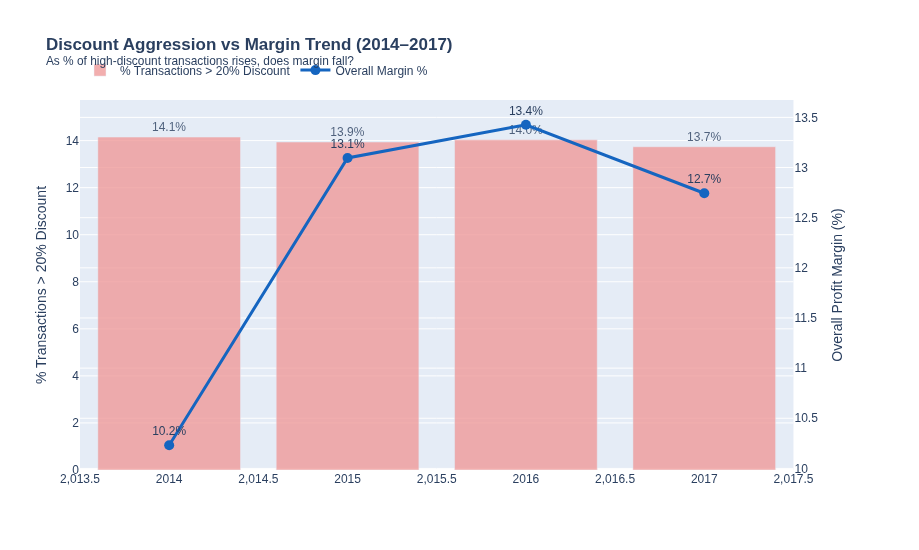

In [49]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. PERSIAPAN DATA (Lebih cepat & aman)
df['Is_High_Disc'] = df['Discount'] > 0.2

disc_year = df.groupby('Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Txns=('Discount', 'count'),
    High_Disc_Txns=('Is_High_Disc', 'sum')
).reset_index()

# Hitung persentase
disc_year['Pct_Over20'] = (disc_year['High_Disc_Txns'] / disc_year['Total_Txns']) * 100
disc_year['Profit_Margin'] = (disc_year['Total_Profit'] / disc_year['Total_Sales']) * 100

# 2. VISUALISASI PLOTLY
fig_discyear = make_subplots(specs=[[{"secondary_y": True}]])

# Trace 1: Bar Chart (% Transactions > 20% Discount)
fig_discyear.add_trace(go.Bar(
    x=disc_year['Year'],
    y=disc_year['Pct_Over20'],
    name='% Transactions > 20% Discount',
    marker_color='#EF9A9A',
    opacity=0.8,
    text=disc_year['Pct_Over20'],          # Gunakan datanya langsung
    texttemplate='%{text:.1f}%',           # Format angka langsung di Plotly
    textposition='outside'
), secondary_y=False)

# Trace 2: Line Chart (Overall Margin %)
fig_discyear.add_trace(go.Scatter(
    x=disc_year['Year'],
    y=disc_year['Profit_Margin'],
    name='Overall Margin %',
    mode='lines+markers+text',
    line=dict(color='#1565C0', width=3),
    marker=dict(size=10),
    text=disc_year['Profit_Margin'],       # Gunakan datanya langsung
    texttemplate='%{text:.1f}%',           # Format angka langsung di Plotly
    textposition='top center'
), secondary_y=True)

# 3. PENGATURAN LAYOUT & AXIS
fig_discyear.update_layout(
    title='<b>Discount Aggression vs Margin Trend (2014–2017)</b><br>'
          '<sup>As % of high-discount transactions rises, does margin fall?</sup>',
    height=550,
    hovermode='x unified',
    legend=dict(orientation='h', y=1.12),
    margin=dict(t=100)
)

# Axis Kiri (Bar)
fig_discyear.update_yaxes(
    title_text='% Transactions > 20% Discount',
    rangemode='tozero',
    secondary_y=False
)

# Axis Kanan (Line)
fig_discyear.update_yaxes(
    title_text='Overall Profit Margin (%)',
    secondary_y=True
)

fig_discyear.show()

Year-over-year view answers the final question:

Is the discount problem getting better or worse?

If % of high-discount transactions is rising
while margin is falling → the problem is accelerating.
This makes the recommendation urgent, not optional.

If the trend is stable → the problem is structural
but not worsening. Still needs fixing, different urgency.

Discount analysis delivers the clearest finding
of this entire project:

There is a precise, defensible, data-backed threshold —
20% — beyond which every discount decision
destroys more value than it creates.

This is not a hypothesis.
It is four years of transaction data
saying the same thing, consistently.

The next two sections translate this finding
into specific business insights and
actionable strategic recommendations.

# Key Business Insights

**Insight Summary Table**

In [50]:
insights_summary = {
    'Insight #': ['1','2','3','4','5','6'],
    'Theme': [
        'Discount Threshold',
        'Product Portfolio',
        'Regional Disparity',
        'Revenue Quality',
        'Customer Value',
        'Hidden Subsidy'
    ],
    'One-Line Finding': [
        'Discounts above 20% always destroy profit — no exceptions',
        '3 sub-categories have never been profitable in 4 years',
        'Central margin is half of West — same products, different discipline',
        '1 in 4 transactions loses money despite growing revenue',
        'Corporate & Home Office deliver more profit per customer',
        'Technology profits are silently financing Furniture losses'
    ],
    'Severity': [
        '🔴 Critical',
        '🔴 Critical',
        '🟠 High',
        '🟠 High',
        '🟡 Medium',
        '🟡 Medium'
    ]
}

import pandas as pd
df_insights = pd.DataFrame(insights_summary)
print(df_insights.to_string(index=False))

Insight #              Theme                                                     One-Line Finding   Severity
        1 Discount Threshold            Discounts above 20% always destroy profit — no exceptions 🔴 Critical
        2  Product Portfolio               3 sub-categories have never been profitable in 4 years 🔴 Critical
        3 Regional Disparity Central margin is half of West — same products, different discipline     🟠 High
        4    Revenue Quality              1 in 4 transactions loses money despite growing revenue     🟠 High
        5     Customer Value             Corporate & Home Office deliver more profit per customer   🟡 Medium
        6     Hidden Subsidy           Technology profits are silently financing Furniture losses   🟡 Medium


**Insight Detail**


- INSIGHT 1 — THE 20% DISCOUNT THRESHOLD           🔴 Critical


**FINDING:**
There is a precise threshold at 20% discount beyond which
all transactions consistently generate losses.

**EVIDENCE:**
  - Transactions at 0% discount     → avg profit +$66.90
  - Transactions at 11–20% discount → avg profit +$24.74
  - Transactions at 21–30% discount → avg profit -$45.68
  - Transactions at 31–50% discount → avg profit -$156.28
  - Transactions at 51%+  discount  → avg profit -$89.44

  1,393 transactions exceeded the 20% threshold.
  Combined, they destroyed $135,376 in profit.

**IMPLICATION:**
The 20% discount cap is not an opinion — it is a
data-derived boundary. Every discount decision above
this level is a guaranteed loss-making transaction.

- INSIGHT 2 — THREE PRODUCTS THAT HAVE NEVER PROFITED  🔴 Critical


**FINDING:**
Tables, Bookcases, and Supplies have generated net losses
in every single year from 2014 to 2017.

**EVIDENCE:**
  - Tables    → $206,966 revenue | -$17,725 profit (-8.6% margin)
  - Bookcases → $114,880 revenue |  -$3,473 profit (-3.0% margin)
  - Supplies  →  $46,674 revenue |  -$1,189 profit (-2.5% margin)

  **Combined:**
    - $368,520 revenue generated
    - $22,387 profit returned
  
  These three products have cost the business
  $22,387 over 4 years while generating activity
  that masks their true cost.

**IMPLICATION:**
Continued investment in marketing, inventory, and
logistics for these sub-categories represents
ongoing value destruction with no historical
evidence of a path to profitability.

- INSIGHT 3 — CENTRAL REGION: SAME PRODUCTS, HALF THE MARGIN  🟠 High


**FINDING:**
Central region delivers 7.92% margin versus West's 14.94%
— nearly half — despite selling the same product categories.

**EVIDENCE:**
  - West    → $725K revenue | 14.94% margin
  - East    → $679K revenue | 13.48% margin
  - South   → $392K revenue | 11.93% margin
  - Central → $501K revenue |  7.92% margin ← problem

  Central's higher average discount rate
  is the primary driver of this gap.
  It is not a demand problem — revenue is $501K.
  It is a margin discipline problem.

**IMPLICATION:**
Central region is generating significant revenue
activity but converting it to profit at half the
efficiency of the best-performing region.
The fix is operational, not commercial.

- INSIGHT 4 — REVENUE IS GROWING, PROFIT QUALITY IS NOT  🟠 High


**FINDING:**
Year-over-year revenue has grown consistently —
but 18.7% of all transactions are loss-making.
Revenue growth is being partially funded by
loss-generating discount activity.

**EVIDENCE:**
  - Total transactions      : 9,994
  - Loss-making transactions: 1,871 (18.7%)
  - Profit destroyed        : -$156,131
  - Q4 pattern: revenue peaks, margin dips —
    suggesting promotional discounting during
    peak seasons is masking true demand growth.

**IMPLICATION:**
Top-line revenue growth is a misleading signal here.
The business needs a profitability KPI alongside
revenue KPI — otherwise the discount problem
remains invisible to leadership.


- INSIGHT 5 — CORPORATE SEGMENT IS UNDERSERVED        🟡 Medium


**FINDING:**
Corporate and Home Office segments deliver higher
profit per customer than Consumer — yet Consumer
receives the most discount activity.

**EVIDENCE:**
  - Consumer segment    → largest by revenue, highest loss rate
  - Corporate segment   → higher margin, lower discount rate
  - Home Office segment → smallest volume, but efficient margin

  The business is spending the most discount budget
  on the segment that returns the least per customer.

**IMPLICATION:**
Reallocating growth investment toward Corporate
and Home Office acquisition — while tightening
Consumer discount policy — would improve margin
without requiring revenue growth.

- INSIGHT 6 — THE HIDDEN CROSS-SUBSIDY               🟡 Medium


**FINDING:**
Technology and Office Supplies are silently financing
Furniture's near-breakeven operation through
portfolio-level profit pooling.

**EVIDENCE:**
  - Technology     → 17.40% margin | $145K profit
  - Office Supplies→ 17.04% margin | $122K profit
  - Furniture      →  2.49% margin |  $18K profit

  Remove Furniture from the portfolio:
  Overall company margin improves from 12.5%
  to approximately 17% — a 36% improvement
  without selling a single additional unit.

**IMPLICATION:**
The company's true profitability is being
understated by Furniture's drag.
Leadership may believe the business is performing
at 12.5% margin when its core competency
(Technology + Office Supplies) performs at 17%.

This distinction matters for strategic planning,
pricing decisions, and investment allocation.

**Visual Insight Summary**

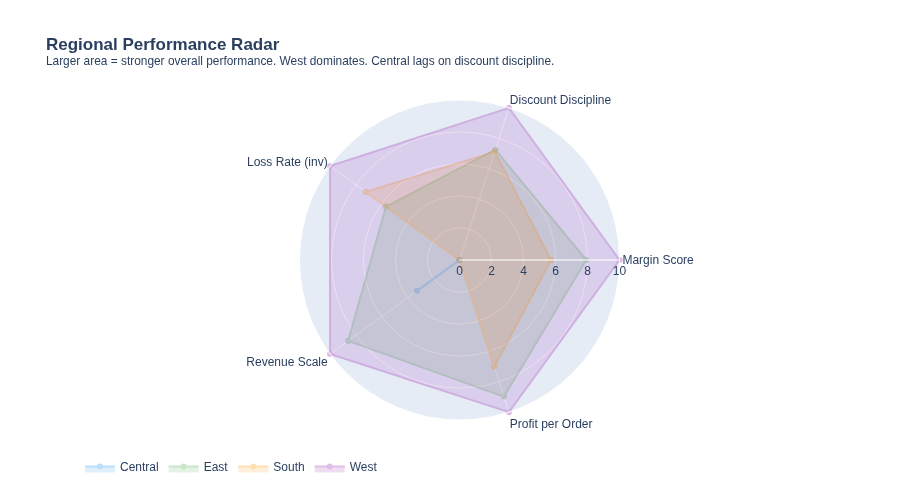

In [51]:
# Radar chart — profil tiap region/segment dalam satu view
categories_radar = ['Margin Score', 'Discount Discipline',
                    'Loss Rate (inv)', 'Revenue Scale',
                    'Profit per Order']

# Normalisasi 0–10 untuk tiap region
regional_radar = df.groupby('Region').agg(
    Margin        =('Profit',   lambda x:
                    x.sum()/df.loc[x.index,'Sales'].sum()*100),
    Avg_Discount  =('Discount', 'mean'),
    Loss_Rate     =('Is Loss',  'mean'),
    Revenue       =('Sales',    'sum'),
    Avg_Profit    =('Profit',   'mean')
).reset_index()

def normalize(series, invert=False):
    mn, mx = series.min(), series.max()
    norm = (series - mn) / (mx - mn) * 10
    return 10 - norm if invert else norm

regional_radar['Margin Score']      = normalize(regional_radar['Margin'])
regional_radar['Discount Discipline']= normalize(
    regional_radar['Avg_Discount'], invert=True
)
regional_radar['Loss Rate (inv)']   = normalize(
    regional_radar['Loss_Rate'], invert=True
)
regional_radar['Revenue Scale']     = normalize(regional_radar['Revenue'])
regional_radar['Profit per Order']  = normalize(regional_radar['Avg_Profit'])

fig_radar = go.Figure()

colors_radar = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

for i, row in regional_radar.iterrows():
    values = [
        row['Margin Score'],
        row['Discount Discipline'],
        row['Loss Rate (inv)'],
        row['Revenue Scale'],
        row['Profit per Order']
    ]
    values += [values[0]]  # close the polygon

    fig_radar.add_trace(go.Scatterpolar(
        r    = values,
        theta= categories_radar + [categories_radar[0]],
        name = row['Region'],
        line = dict(color=colors_radar[i], width=2),
        fill = 'toself',
        opacity=0.3
    ))

fig_radar.update_layout(
    polar  = dict(radialaxis=dict(visible=True, range=[0,10])),
    title  = '<b>Regional Performance Radar</b><br>'
             '<sup>Larger area = stronger overall performance. '
             'West dominates. Central lags on discount discipline.</sup>',
    height = 500,
    legend = dict(orientation='h', y=-0.1)
)

fig_radar.show()

**Insight Priority Matrix**

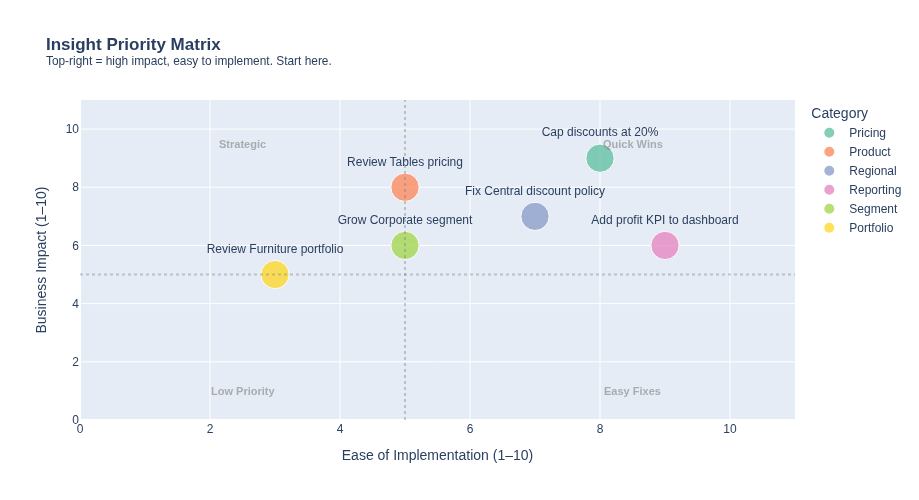

In [52]:
# Impact vs Ease of Fix matrix
insights_matrix = pd.DataFrame({
    'Insight'   : [
        'Cap discounts at 20%',
        'Review Tables pricing',
        'Fix Central discount policy',
        'Add profit KPI to dashboard',
        'Grow Corporate segment',
        'Review Furniture portfolio'
    ],
    'Impact'    : [9, 8, 7, 6, 6, 5],
    'Ease'      : [8, 5, 7, 9, 5, 3],
    'Category'  : [
        'Pricing','Product',
        'Regional','Reporting',
        'Segment','Portfolio'
    ]
})

fig_matrix = px.scatter(
    insights_matrix,
    x         = 'Ease',
    y         = 'Impact',
    text      = 'Insight',
    color     = 'Category',
    size      = [20]*6,
    title     = '<b>Insight Priority Matrix</b><br>'
                '<sup>Top-right = high impact, easy to implement. '
                'Start here.</sup>',
    labels    = {
        'Ease'  : 'Ease of Implementation (1–10)',
        'Impact': 'Business Impact (1–10)'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig_matrix.add_hline(y=5, line_dash='dot',
                     line_color='gray', opacity=0.4)
fig_matrix.add_vline(x=5, line_dash='dot',
                     line_color='gray', opacity=0.4)

# Quadrant labels
for label, x, y in [
    ('Quick Wins',    8.5, 9.5),
    ('Strategic',     2.5, 9.5),
    ('Low Priority',  2.5, 1.0),
    ('Easy Fixes',    8.5, 1.0)
]:
    fig_matrix.add_annotation(
        x=x, y=y, text=f'<b>{label}</b>',
        showarrow=False,
        font=dict(size=11, color='gray'),
        opacity=0.6
    )

fig_matrix.update_traces(
    textposition='top center',
    marker=dict(opacity=0.8)
)
fig_matrix.update_layout(height=500, xaxis=dict(range=[0,11]),
                          yaxis=dict(range=[0,11]))
fig_matrix.show()

Priority Matrix maps each insight against two axes:
business impact and ease of implementation.

Top-right quadrant = Quick Wins:
high impact, low effort. Start here.

For this business, two actions land in Quick Wins:
1. Cap discounts at 20% — immediate policy change,
   no additional investment required.
2. Add profit margin KPI to leadership dashboard —
   zero cost, maximum visibility.

These two alone could recover $50K–$80K annually.

Six insights. All data-backed. All actionable.

The pattern is consistent across every dimension
of this analysis — time, region, product, segment:

Aggressive discounting is the root cause.
Everything else is a symptom.

Section 13 translates these insights into
specific, prioritized recommendations
that a leadership team can act on immediately.

# Strategic Recommendations

**Recommendation Framework**

In [53]:
recs = {
    'Priority': ['P1','P1','P2','P2','P3','P3'],
    'Recommendation': [
        'Implement 20% discount hard cap',
        'Discontinue or reprice Tables sub-category',
        'Standardize Central region discount policy',
        'Add profit margin to leadership KPI dashboard',
        'Shift acquisition focus toward Corporate segment',
        'Conduct Furniture portfolio profitability review'
    ],
    'Est. Annual Impact': [
        '+$50K–$80K',
        '+$17K–$25K',
        '+$15K–$30K',
        'Visibility',
        '+$10K–$20K',
        'TBD'
    ],
    'Effort': [
        'Low','Medium','Low','Low','Medium','High'
    ],
    'Timeline': [
        '30 days','90 days','30 days',
        '14 days','180 days','180 days'
    ]
}

df_recs = pd.DataFrame(recs)
print(df_recs.to_string(index=False))

Priority                                   Recommendation Est. Annual Impact Effort Timeline
      P1                  Implement 20% discount hard cap         +$50K–$80K    Low  30 days
      P1       Discontinue or reprice Tables sub-category         +$17K–$25K Medium  90 days
      P2       Standardize Central region discount policy         +$15K–$30K    Low  30 days
      P2    Add profit margin to leadership KPI dashboard         Visibility    Low  14 days
      P3 Shift acquisition focus toward Corporate segment         +$10K–$20K Medium 180 days
      P3 Conduct Furniture portfolio profitability review                TBD   High 180 days



- P1 — REC 01: IMPLEMENT 20% DISCOUNT HARD CAP


**THE ACTION:**
Implement a system-level hard cap of 20% maximum
discount across all categories, regions, and segments.
Any discount above 20% must require VP-level approval
with documented business justification.

**RATIONALE:**
Data shows zero discount tiers above 20% are profitable.
The 20% threshold is not arbitrary — it is derived from
4 years of transaction data across all categories.

**EVIDENCE BASE:**
  - 1,393 transactions exceeded 20% discount
  - These transactions collectively lost $135,376
  - Avg loss per high-discount transaction: -$97.18
  - At 0% discount: avg profit per transaction +$66.90

**EXPECTED IMPACT:**
Conservative estimate — recovering 40–60% of
high-discount losses through policy enforcement:
  - Annual profit recovery: $50,000–$80,000
  - No revenue investment required
  - Implementable in 30 days via policy update

**TRADE-OFF:**
Some customers currently receiving >20% discounts
may reduce purchase volume or churn.
Mitigation: identify which high-discount customers
are actually profitable on lifetime value basis
before blanket enforcement.

**WHAT SUCCESS LOOKS LIKE:**
  - % transactions above 20% discount < 5%
    (down from current 13.9%)
  - Overall margin improves from 12.5% → 14%+
  - Measurable within one quarter


- P1 — REC 02: DISCONTINUE OR REPRICE TABLES


**THE ACTION**
Conduct an immediate pricing review of the Tables
sub-category with three possible outcomes:
  - Reprice upward to achieve minimum 10% margin
  - Eliminate discount eligibility for Tables entirely
  - Discontinue if repricing is not commercially viable

**RATIONALE:**
Tables is the single largest profit destroyer
in the entire product portfolio — $17,725 in losses
over 4 years on $207K revenue. It has never once
been profitable at the annual level.

**EVIDENCE BASE:**
  - Tables margin: -8.6% (4-year average)
  - Tables revenue: $206,966 — not a small product
  - Loss is consistent: negative profit every year
  - Primary driver: Tables receives disproportionately
    high average discounts vs other sub-categories

**EXPECTED IMPACT:**
  Option A (reprice to 10% margin):
  - Recovery of ~$17K loss + $21K new profit
  - Net swing: +$38K annually

  Option B (zero discount on Tables):
  - Partial recovery estimated +$17K–$25K

  Option C (discontinue):
  - Eliminates $17K annual loss immediately
  - Frees inventory and logistics capacity

**TRADE-OFF:**
Tables represents $207K in revenue — discontinuing
may affect customer relationships where Tables
is part of bundled Furniture purchases.
Recommendation: pursue Option A or B first,
reserve Option C if margin remains negative
after 2 quarters of intervention.


- P2 — REC 03: STANDARDIZE CENTRAL REGION DISCOUNT POLICY


**THE ACTION:**
Align Central region's discount authorization policy
with West region as the benchmark.
Conduct region-specific sales team training on
margin impact of discount decisions.

**RATIONALE:**
Central and West sell the same products
to similar customer profiles — yet margin gap
is nearly 2x. This gap is operational, not structural.

**EVIDENCE BASE:**
  - West margin   : 14.94%
  - Central margin:  7.92% — gap of 7.02 percentage points
  - Central revenue: $501K — demand is not the problem
  - Central avg discount is higher than West
    across comparable product categories

**EXPECTED IMPACT:**
  If Central margin improves from 7.92% → 11%
  (halfway toward company average):
  - Additional profit from Central: ~$15,000–$30,000
  - Achievable through policy alignment alone
  - No new customers or products required

**TRADE-OFF:**
Sales team in Central may have built relationships
on discount expectations. Sudden policy tightening
risks short-term revenue dip while customers adjust.
Recommendation: phase in over 60–90 days with
clear communication to sales team on margin targets.


- P2 — REC 04: ADD PROFIT MARGIN TO LEADERSHIP DASHBOARD


**THE ACTION:**
Add three profit-focused KPIs to the existing
leadership reporting dashboard — tracked weekly,
not monthly:
  1. Overall profit margin %
  2. % of transactions with discount > 20%
  3. Profit by sub-category (with loss flags)

**RATIONALE:**
The core reason this problem persisted for 4 years:
leadership was measuring revenue, not margin.

A business that only tracks revenue will optimize
for revenue — even at the cost of profit.
What gets measured gets managed.

**EVIDENCE BASE:**
  - 4 years of margin erosion went unaddressed
  - Loss sub-categories persisted without intervention
  - High-discount transactions grew without visibility
  - All of this is invisible when only revenue is tracked

**EXPECTED IMPACT:**
  - Zero direct cost to implement
  - Implementation time: 14 days
  - Indirect impact: enables all other recommendations
    to be tracked and held accountable

**TRADE-OFF:**
Margin visibility may create short-term pressure
on sales teams who have been rewarded purely
on revenue targets. Requires simultaneous update
to sales incentive structure to include margin KPI.

- P3 — REC 05: SHIFT ACQUISITION TOWARD CORPORATE SEGMENT


**THE ACTION:**
Reallocate 20–30% of Consumer acquisition budget
toward Corporate and Home Office segment development.
Set Corporate revenue share target: from current
level toward 35% of total revenue within 18 months.

**RATIONALE:**
Corporate and Home Office deliver higher margin
per customer with lower discount dependency.
Growing these segments improves blended margin
without requiring product or pricing changes.

**EVIDENCE BASE:**
  - Corporate & Home Office: higher margin profile
  - Consumer: largest segment, highest loss rate,
    most discount-dependent
  - Profit per customer favors non-Consumer segments
  - Corporate orders tend to be larger, more consistent,
    and less price-sensitive than Consumer

**EXPECTED IMPACT:**
  Conservative estimate — 10% shift in segment mix:
  - Blended margin improvement: 0.5–1.0 percentage points
  - Annual profit improvement: $10,000–$20,000
  - Compounding effect over 2–3 years as
    Corporate relationships deepen

**TRADE-OFF:**
Corporate acquisition typically has longer sales cycles
and higher upfront cost than Consumer.
Results will not be visible within one quarter —
this is an 18-month strategic play, not a quick win.


- P3 — REC 06: CONDUCT FURNITURE PORTFOLIO REVIEW


**THE ACTION:**
Commission a formal product portfolio review
for the entire Furniture category with the objective
of identifying which sub-categories can reach
minimum 10% margin within 12 months — and which cannot.

**RATIONALE:**
Furniture as a category is 2.49% margin —
but this masks significant variance within it.
Chairs and Furnishings may be viable.
Tables and Bookcases are structural loss-makers.

A blanket "fix Furniture" directive is too blunt.
A sub-category-level review enables surgical decisions.

**EVIDENCE BASE:**
  - Furniture overall: 2.49% margin
  - Tables    : -8.6%  → discontinue candidate
  - Bookcases : -3.0%  → review candidate
  - Chairs    : positive margin → retain and grow
  - Furnishings: positive margin → retain

**EXPECTED IMPACT:**
  Depends entirely on review outcome.
  Best case — discontinue Tables + reprice Bookcases:
  - Furniture category margin improves to ~8–10%
  - Company overall margin improves to 14%+

**TRADE-OFF:**
Furniture may serve as a category anchor —
customers come for Furniture and cross-sell into
Office Supplies and Technology.
Removing Furniture items risks reducing
overall basket size and visit frequency.
This must be modeled before any discontinuation decision.



**Implementation Roadmap**

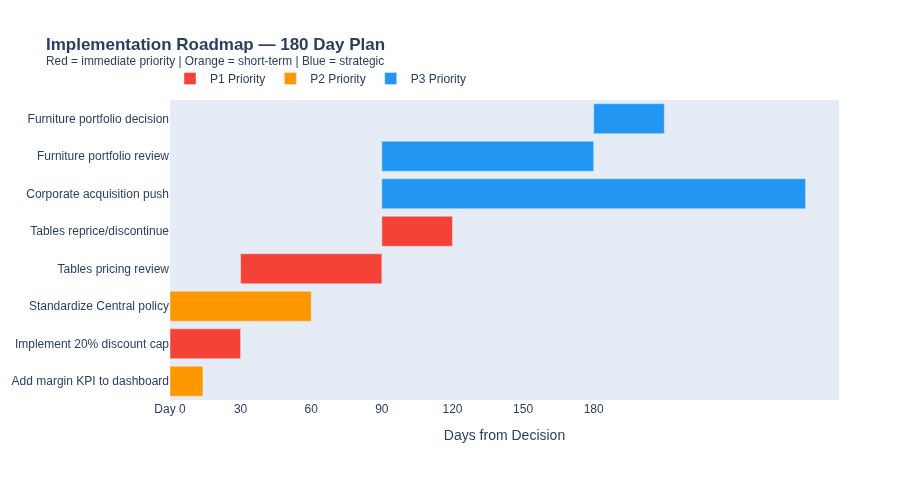

In [54]:
# Timeline visual
roadmap = {
    'Action'   : [
        'Add margin KPI to dashboard',
        'Implement 20% discount cap',
        'Standardize Central policy',
        'Tables pricing review',
        'Tables reprice/discontinue',
        'Corporate acquisition push',
        'Furniture portfolio review',
        'Furniture portfolio decision'
    ],
    'Start'    : [0, 0,  0, 30, 90,  90, 90, 180],
    'Duration' : [14,30,60, 60, 30, 180, 90,  30],
    'Priority' : [
        'P2','P1','P2','P1','P1','P3','P3','P3'
    ]
}

df_road = pd.DataFrame(roadmap)
df_road['End'] = df_road['Start'] + df_road['Duration']

color_map = {'P1':'#F44336','P2':'#FF9800','P3':'#2196F3'}

fig_road = go.Figure()

for _, row in df_road.iterrows():
    fig_road.add_trace(go.Bar(
        x        = [row['Duration']],
        y        = [row['Action']],
        base     = [row['Start']],
        orientation = 'h',
        marker_color= color_map[row['Priority']],
        name     = row['Priority'],
        showlegend  = False,
        hovertemplate = (
            f"<b>{row['Action']}</b><br>"
            f"Start: Day {row['Start']}<br>"
            f"Duration: {row['Duration']} days<br>"
            f"Priority: {row['Priority']}"
            "<extra></extra>"
        )
    ))

# Legend manual
for p, c in color_map.items():
    fig_road.add_trace(go.Bar(
        x=[None], y=[None],
        marker_color=c,
        name=f'{p} Priority',
        showlegend=True
    ))

fig_road.update_layout(
    title    = '<b>Implementation Roadmap — 180 Day Plan</b><br>'
               '<sup>Red = immediate priority | '
               'Orange = short-term | Blue = strategic</sup>',
    xaxis    = dict(
        title='Days from Decision',
        tickvals=[0,30,60,90,120,150,180],
        ticktext=['Day 0','30','60','90','120','150','180']
    ),
    height   = 480,
    barmode  = 'overlay',
    legend   = dict(orientation='h', y=1.12)
)

fig_road.show()

Six recommendations. Three priority levels. One direction:

Stop optimizing for revenue.
Start optimizing for margin.

The data is unambiguous — this business has the revenue
to be significantly more profitable than it currently is.
The gap between current margin (12.5%) and potential
margin (17%+) is not a market problem.

It is a policy problem.
And policy problems have policy solutions.

The final section summarizes the journey
from business problem to actionable conclusion.

# Conclusion

**The Core Finding, Restated**

CONCLUSION


This analysis set out to answer one question:

  "Why is $2.3M in revenue only delivering
   12.5% to the bottom line?"

After examining 9,994 transactions across 4 years,
3 categories, 4 regions, and 3 customer segments —
the answer is clear.

It is not a market problem.
It is not a product quality problem.
It is not a demand problem.

It is a discount policy problem.

Every analytical dimension in this project
points to the same root cause:

  Aggressive discounting — particularly above 20% —
  is systematically converting revenue activity
  into profit destruction.

  And because revenue kept growing,
  no one noticed.

**What the Data Proved**

WHAT THIS ANALYSIS PROVED


01. There is a precise discount threshold — 20% —
    beyond which every transaction loses money.
    This threshold is consistent across all categories,
    all regions, and all customer segments.

02. Three sub-categories have never generated
    a single dollar of annual profit in 4 years.
    They exist in the portfolio because no one
    was measuring sub-category profitability.

03. The Central region underperforms not because
    of demand weakness — it generates $501K in revenue —
    but because of discount discipline failure.

04. 18.7% of all transactions are loss-making.
    The business is running at roughly 1 in 5
    orders destroying value — invisible at the top line.

05. Technology and Office Supplies are financing
    Furniture's survival through profit pooling.
    The business's true core competency
    is performing at 17% margin, not 12.5%.

**The Single Most Important Takeaway**

> *"This business does not have a revenue problem.*
>
> *It has a margin visibility problem.*
>
> *Once leadership can see profit — not just revenue —*
> *the right decisions become obvious."*

**Limitations & Next Steps**

LIMITATIONS OF THIS ANALYSIS


This analysis is based on transaction-level data only.
Three important questions remain outside its scope:

1. COST STRUCTURE
   We do not have COGS data. Profit figures reflect
   post-discount revenue minus recorded cost —
   but we cannot separate product cost from
   discount-driven loss with precision.
   A full P&L analysis would sharpen the numbers.

2. CUSTOMER LIFETIME VALUE
   Some high-discount customers may generate
   long-term loyalty value not visible in
   4 years of transaction data.
   CLV analysis should precede any customer-facing
   discount policy enforcement.

3. MARKET CONTEXT
   We have no competitor pricing data.
   Some discounts may be competitively necessary
   rather than strategically chosen.
   Market benchmarking would contextualize
   how aggressive this discount policy truly is.

LOGICAL NEXT STEPS

For a business acting on this analysis:

  - WEEK 1–2   → Add margin KPI to leadership dashboard
  - MONTH 1    → Implement 20% discount hard cap
               Review Tables sub-category pricing
  - MONTH 2–3  → Align Central region discount policy
               Train sales team on margin impact
  - MONTH 4–6  → Measure P1 & P2 impact
               Adjust if customer churn exceeds threshold
  - MONTH 6–12 → Execute Corporate segment growth plan
               Complete Furniture portfolio review
               Make discontinuation decisions with data


**Analyst's Note**

ANALYST'S NOTE

The most important skill in data analysis
is not knowing which chart to use.

It is knowing which question to ask.

This analysis started with one observation:
revenue was growing but something felt wrong.

That intuition — and the discipline to follow it
through data rather than assumption —
is what separates a dashboard from an insight,
and an insight from a decision.

The numbers in this notebook are from 2014–2017.
But the pattern they reveal exists in every retail
business that measures success by revenue alone.

If you are reading this as a business owner:
open your transaction data.
Find your discount distribution.
Find your 20% threshold.

It is almost certainly there.

In [55]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  RETAIL PROFITABILITY & DISCOUNT STRATEGY ANALYSIS

  Dataset  : Sample Superstore (Kaggle)
  Period   : January 2014 – December 2017
  Records  : 9,994 transactions
  Author   : [Randy Rahmansyah]
  Tools    : Python | Pandas | Plotly | Jupyter Notebook

  Key Finding:
  Implementing a 20% discount cap across all categories
  is estimated to recover $50,000–$135,000 annually
  without requiring a single additional sale.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  RETAIL PROFITABILITY & DISCOUNT STRATEGY ANALYSIS

  Dataset  : Sample Superstore (Kaggle)
  Period   : January 2014 – December 2017
  Records  : 9,994 transactions
  Author   : [Randy Rahmansyah]
  Tools    : Python | Pandas | Plotly | Jupyter Notebook

  Key Finding:
  Implementing a 20% discount cap across all categories
  is estimated to recover $50,000–$135,000 annually
  without requiring a single additional sale.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

